<a href="https://colab.research.google.com/github/ngyxntthaoo/IS6404.CH201-Phan-tich-du-lieu-nang-cao/blob/main/Lab04c_Lec06_TimeSeries_ML_Forecasting_PTDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Cấu trúc notebook (theo phase)

| Phase | Nội dung |
|------|----------|
| 1 | Giới thiệu, setup, seed, `OUTPUT_DIR` |
| 2 | Phát biểu bài toán + load & preview dữ liệu |
| 3 | EDA |
| 4 | Time-based split (Q&A) + code |
| 5 | Evaluation metrics |
| 6 | Baseline: classical → ML → Chronos-Bolt |
| 7 | Proposed: Chronos-2, blend, HPO, feature importance |
| 8 | So sánh validation |
| 9 | Error analysis (proposed) |
| 10 | Ablation (proposed) |
| 11 | Final test (+ bảng theo nhóm) |
| 12 | Visualize test |
| 13 | Lưu kết quả — `outputs/` |


# Phase 1 — Setup & reproducibility

In [ ]:


import os, json, sys, platform, warnings

from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("python:", sys.version)
print("platform:", platform.platform())
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

warnings.filterwarnings("ignore")


python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
platform: Linux-6.6.122+-x86_64-with-glibc2.35
numpy: 2.0.2
pandas: 2.3.3


# Phase 2 — Problem formulation

Bài toán: **dự báo nhu cầu bán lẻ đa chuỗi** — 100 chuỗi thời gian hàng ngày (5 stores × 20 products).

### Phát biểu chính thức

| Yếu tố | Giá trị |
|---|---|
| **Target** | `Units Sold` — số lượng bán ra mỗi ngày, per (Store, Product) |
| **Frequency** | Daily |
| **Forecast horizon H** | **7 ngày** (`HORIZON_DAYS = 7`) |
| **Forecast origin** | Val: `2023-06-30` · Test: `2023-10-31` |
| **Prediction type** | **Multi-step** — dự báo đồng thời $\hat{y}_{t+1}, \ldots, \hat{y}_{t+7}$ từ một forecast origin |
| **Số chuỗi** | N = 100 (5 stores × 20 products) |


### Load & preview dataset

**Kaggle:** thêm dataset có `sales_data.csv` (ví dụ *Retail Store…*). Ô code tìm ` /kaggle/input/**/sales_data.csv` tự động. Nếu thiếu file, sẽ `FileNotFoundError` với hướng dẫn. Kaggle *Input* thường đủ, không cần mạng; mạng/`kagglehub` chỉ khi dùng fallback tải từ hub (mở comment ở ô pip trước ô load).


In [2]:
import os

print(os.listdir("/kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting"))

['sales_data.csv']


In [3]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atomicd/retail-store-inventory-and-demand-forecasting")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "sales_data.csv"))

Path to dataset files: /kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting


In [4]:
DATA_PATH = '/kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting/sales_data.csv'
print("Path to dataset file:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df

Path to dataset file: /kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting/sales_data.csv


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


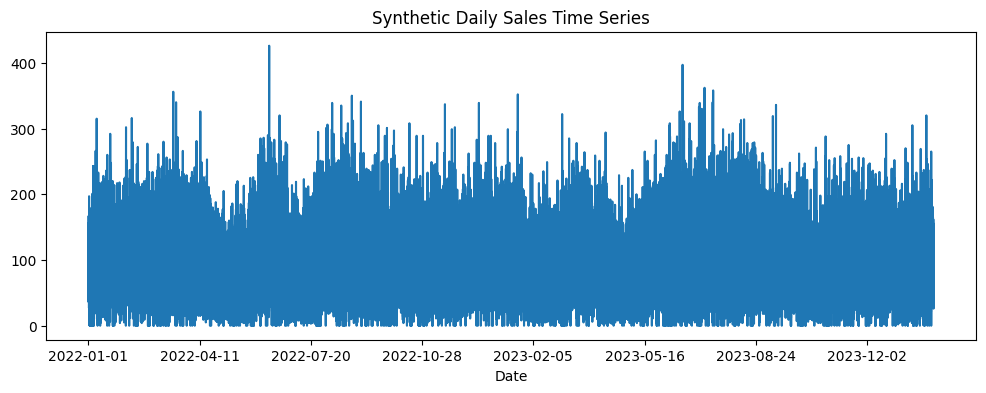

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [5]:
df.set_index("Date")["Units Sold"].plot(figsize=(12,4), title="Synthetic Daily Sales Time Series")
plt.show()

df.describe()


# Phase 3 — EDA — Phân tích đặc trưng dữ liệu

Trước khi chọn mô hình, cần kiểm tra 6 đặc trưng bắt buộc theo checklist:

| # | Đặc trưng | Cách kiểm tra |
|---|---|---|
| 2.1 | **Trend** | Seasonal decomposition — có trend tăng/giảm dài hạn không? |
| 2.2 | **Seasonality** | ACF/PACF — có autocorrelation ở lag 7, 14, 28? |
| 2.3 | **Noise level** | Residual từ decomposition — noise có lớn so với signal không? |
| 2.4 | **Regime changes** | Plot rolling mean — có điểm gãy đột ngột (epidemic, policy change)? |
| 2.5 | **Shock/outlier events** | Rolling z-score > 3σ |
| 2.6 | **Stationarity** | ADF test — p-value < 0.05 → stationary |

> **Tại sao quan trọng:** Nếu chuỗi không stationary → ARIMA cần d>0. Nếu có strong seasonality lag=7 → seasonal naive mạnh hơn naive. Nếu có regime change → train window cần được giới hạn.


📊 [2.1 / 2.3 / 2.4] Seasonal Decomposition — Tách chuỗi thành các thành phần


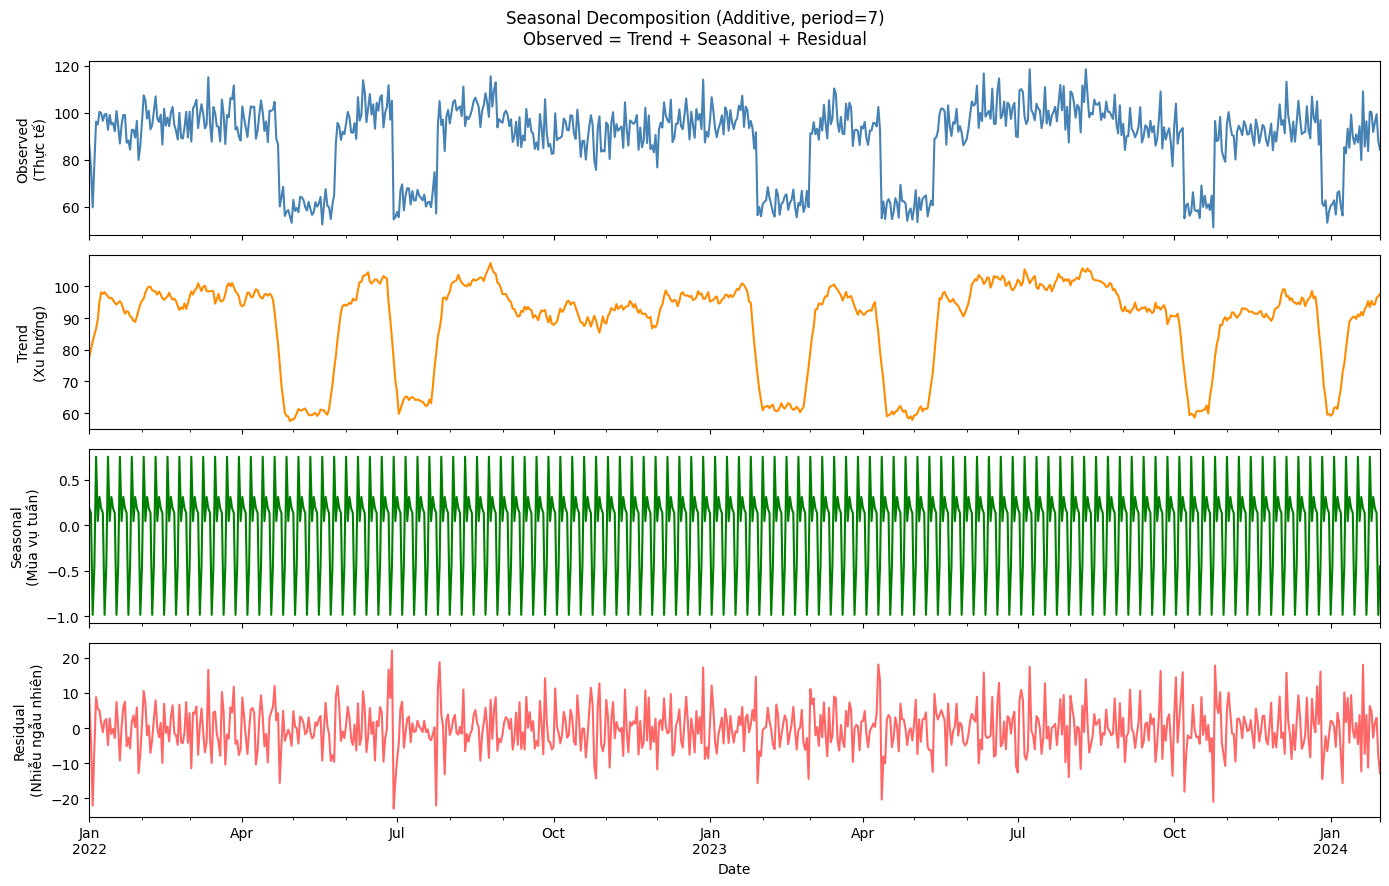


→ Tỷ lệ nhiễu (resid_std / total_std) : 0.405
  ⚠️  Nhiễu cao — cần model phi tuyến (HGB, LightGBM)
→ Biên độ Trend  : 49.92 units  (trend tăng/giảm rõ)
→ Biên độ Seasonal: 1.74 units  (weekly pattern yếu)

📊 [2.2] ACF / PACF — Kiểm tra Autocorrelation và Seasonality
  Cách đọc: spike tại lag 7, 14, 21 → weekly seasonality mạnh
  PACF tắt nhanh sau lag p → AR(p) phù hợp cho ARIMA


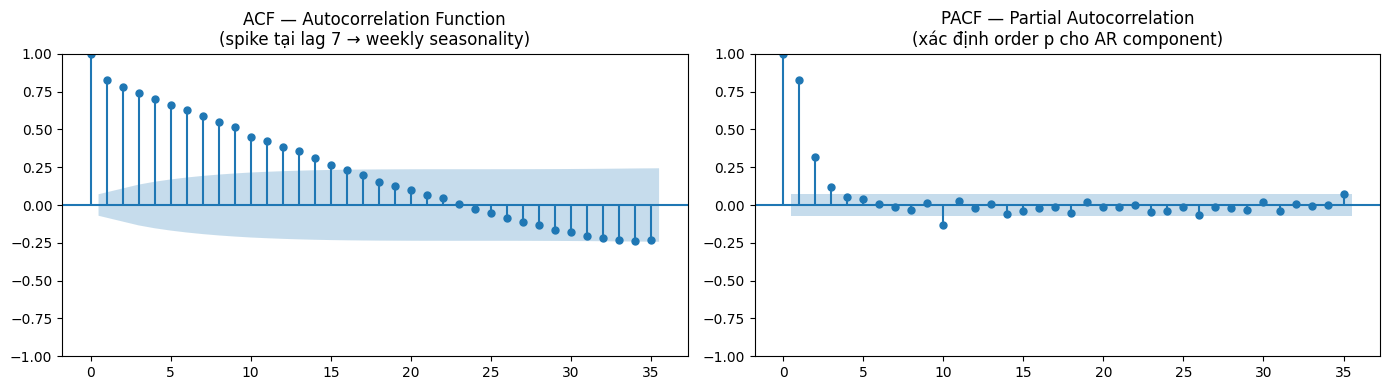


📊 [2.6] ADF Stationarity Test — Kiểm tra tính dừng của chuỗi
  ADF Statistic : -4.9190
  p-value       : 0.000032
  ✅ Stationary (p < 0.05) — ARIMA dùng d=0; không cần differencing
  ✅ Critical [1%]: -3.4391
  ✅ Critical [5%]: -2.8654
  ✅ Critical [10%]: -2.5688

📊 [2.5] Shock / Outlier Detection — Phát hiện ngày demand bất thường
  Số ngày bất thường (|z|>3): 0 / 760 ngày (0.0%)
  ✅  Ít shock — dữ liệu tương đối ổn định


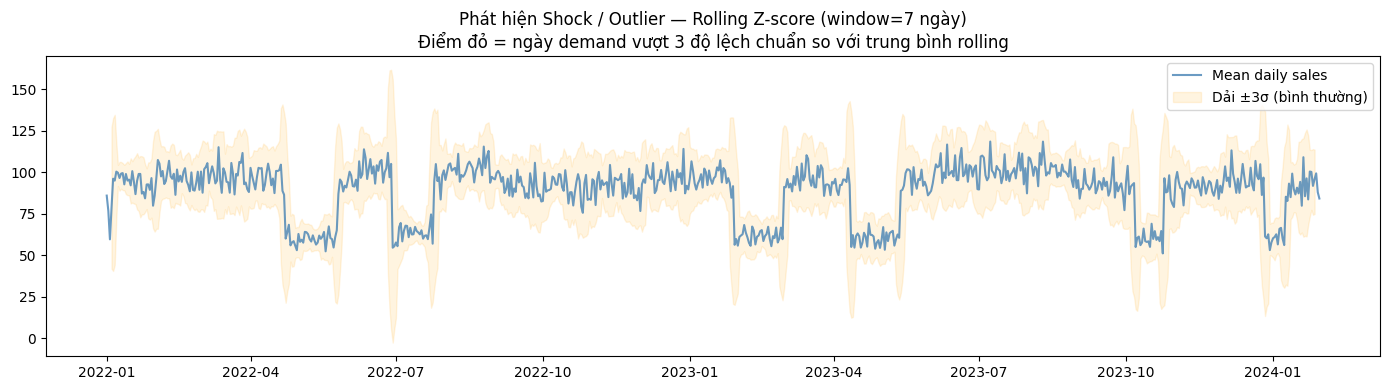

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Dùng aggregate mean làm chuỗi đại diện (100 series → 1 chuỗi trung bình theo ngày)
ts_agg = df.groupby("Date")["Units Sold"].mean().sort_index()
ts_agg.index = pd.to_datetime(ts_agg.index)

# ── 2.1, 2.3, 2.4: Seasonal Decomposition ────────────────────────────────────
# Tách chuỗi thành: Observed = Trend + Seasonal + Residual
# period=7 vì dữ liệu daily với weekly seasonality
print("📊 [2.1 / 2.3 / 2.4] Seasonal Decomposition — Tách chuỗi thành các thành phần")
decomp = seasonal_decompose(ts_agg, model="additive", period=7, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
decomp.observed.plot(ax=axes[0], color="steelblue")
axes[0].set_ylabel("Observed\n(Thực tế)")
decomp.trend.plot(ax=axes[1], color="darkorange")
axes[1].set_ylabel("Trend\n(Xu hướng)")
decomp.seasonal.plot(ax=axes[2], color="green")
axes[2].set_ylabel("Seasonal\n(Mùa vụ tuần)")
decomp.resid.plot(ax=axes[3], color="red", alpha=0.6)
axes[3].set_ylabel("Residual\n(Nhiễu ngẫu nhiên)")
fig.suptitle("Seasonal Decomposition (Additive, period=7)\n"
             "Observed = Trend + Seasonal + Residual", fontsize=12)
plt.tight_layout()
plt.show()

noise_ratio = decomp.resid.dropna().std() / decomp.observed.std()
trend_range = decomp.trend.dropna().max() - decomp.trend.dropna().min()
seasonal_amp = decomp.seasonal.max() - decomp.seasonal.min()

print(f"\n→ Tỷ lệ nhiễu (resid_std / total_std) : {noise_ratio:.3f}")
print(f"  {'⚠️  Nhiễu cao — cần model phi tuyến (HGB, LightGBM)' if noise_ratio > 0.3 else '✅  Nhiễu thấp — statistical models có thể đủ tốt'}")
print(f"→ Biên độ Trend  : {trend_range:.2f} units  (trend {'tăng/giảm rõ' if trend_range > 5 else 'phẳng'})")
print(f"→ Biên độ Seasonal: {seasonal_amp:.2f} units  (weekly pattern {'mạnh' if seasonal_amp > 5 else 'yếu'})")

# ── 2.2: ACF / PACF ──────────────────────────────────────────────────────────
# ACF: đo tương quan giữa chuỗi và phiên bản trễ h bước
# PACF: đo tương quan thuần túy tại lag h (loại bỏ ảnh hưởng của các lag trung gian)
print("\n📊 [2.2] ACF / PACF — Kiểm tra Autocorrelation và Seasonality")
print("  Cách đọc: spike tại lag 7, 14, 21 → weekly seasonality mạnh")
print("  PACF tắt nhanh sau lag p → AR(p) phù hợp cho ARIMA")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_agg.dropna(),  lags=35, ax=axes[0],
         title="ACF — Autocorrelation Function\n(spike tại lag 7 → weekly seasonality)")
plot_pacf(ts_agg.dropna(), lags=35, ax=axes[1],
          title="PACF — Partial Autocorrelation\n(xác định order p cho AR component)")
plt.tight_layout()
plt.show()

# ── 2.6: ADF Stationarity Test ───────────────────────────────────────────────
# Kiểm định ADF (Augmented Dickey-Fuller): H0 = chuỗi có unit root (non-stationary)
# p < 0.05 → bác bỏ H0 → chuỗi stationary → ARIMA với d=0
print("\n📊 [2.6] ADF Stationarity Test — Kiểm tra tính dừng của chuỗi")
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(ts_agg.dropna(), autolag="AIC")
print(f"  ADF Statistic : {adf_stat:.4f}")
print(f"  p-value       : {adf_p:.6f}")
if adf_p < 0.05:
    print("  ✅ Stationary (p < 0.05) — ARIMA dùng d=0; không cần differencing")
else:
    print("  ❌ Non-stationary (p ≥ 0.05) — cần differencing, dùng ARIMA với d=1")
for level, cv in adf_crit.items():
    marker = "✅" if adf_stat < cv else "  "
    print(f"  {marker} Critical [{level}]: {cv:.4f}")

# ── 2.5: Shock / Outlier Detection ───────────────────────────────────────────
# Dùng rolling z-score để phát hiện ngày có demand bất thường
# z = (y - rolling_mean) / rolling_std; |z| > 3 → outlier
print("\n📊 [2.5] Shock / Outlier Detection — Phát hiện ngày demand bất thường")
roll_mean = ts_agg.rolling(window=7, center=True).mean()
roll_std  = ts_agg.rolling(window=7, center=True).std()
z_scores  = (ts_agg - roll_mean) / (roll_std + 1e-8)
outliers  = ts_agg[z_scores.abs() > 3]
pct = 100 * len(outliers) / len(ts_agg)
print(f"  Số ngày bất thường (|z|>3): {len(outliers)} / {len(ts_agg)} ngày ({pct:.1f}%)")
print(f"  {'⚠️  Có shock events — cần exogenous features (Promotion, Epidemic)' if pct > 1 else '✅  Ít shock — dữ liệu tương đối ổn định'}")

plt.figure(figsize=(14, 4))
plt.plot(ts_agg.index, ts_agg.values, label="Mean daily sales", alpha=0.8, color="steelblue")
if len(outliers):
    plt.scatter(outliers.index, outliers.values, color="red", zorder=5, s=40,
                label=f"Shock/Outlier ({len(outliers)} ngày, |z|>3σ)")
plt.fill_between(ts_agg.index, roll_mean - 3*roll_std, roll_mean + 3*roll_std,
                 alpha=0.12, color="orange", label="Dải ±3σ (bình thường)")
plt.legend(loc="upper right")
plt.title("Phát hiện Shock / Outlier — Rolling Z-score (window=7 ngày)\n"
          "Điểm đỏ = ngày demand vượt 3 độ lệch chuẩn so với trung bình rolling")
plt.tight_layout()
plt.show()

### Giải thích Kết quả EDA — Ý nghĩa và Quyết định Mô hình

#### 2.1 Trend (Xu hướng dài hạn)
- **Trend tăng/giảm rõ** → cần model có trend component: `Prophet` (trend='linear'), `ETS` (trend='add'), hoặc feature `dayofyear` trong HGB.
- **Trend phẳng** → baseline Naive đủ mạnh làm reference; ARIMA với d=0 có thể hoạt động.
- **Trend có điểm gãy** (ví dụ: epidemic gây drop đột ngột) → xem xét giới hạn train window về phía gần forecast origin.

#### 2.2 Seasonality — Đọc ACF/PACF
| Quan sát | Ý nghĩa | Quyết định |
|---|---|---|
| ACF spike tại lag 7, 14, 21 | Weekly seasonality mạnh | Dùng `lag_7`, `lag_14` làm features; seasonal naive là baseline tốt |
| PACF tắt sau lag p | AR(p) phù hợp | ARIMA(p,d,q) với p theo PACF |
| ACF giảm chậm, không tắt | Non-stationary | Cần differencing (d=1) trong ARIMA |
| Không có spike rõ | Noise > signal | Tree-based model (HGB, LightGBM) có thể vượt trội |

#### 2.3 Noise Level (Tỷ lệ nhiễu)
- **Noise-to-signal > 0.5** → nhiễu chiếm ưu thế → các model phức tạp có thể overfit; cần regularization.
- **Noise-to-signal 0.2–0.5** → cần model phi tuyến (HGB) để nắm bắt pattern.
- **Noise-to-signal < 0.2** → signal sạch → statistical models (ARIMA, ETS) có thể cạnh tranh với ML.

#### 2.4 Regime Changes (Thay đổi chế độ)
- Nhìn vào Trend component: nếu có gãy đột ngột → train window quá dài có thể làm model học pattern cũ.
- Dữ liệu có cột `Epidemic` → đây là external regime indicator; cần đưa vào model như exogenous feature.

#### 2.5 Shock/Outlier Events
- **Nhiều outlier (>2%)** → exogenous features (`Promotion`, `Epidemic`) là thiết yếu để giải thích spikes.
- **Ít outlier (<1%)** → demand tương đối ổn định; lag features đã đủ.
- Outlier ảnh hưởng mạnh đến RMSE (bình phương lỗi) → đây là property mong muốn để penalize large errors trong inventory context.

#### 2.6 Stationarity — ADF Test
- **p < 0.05 → Stationary ✅**: dùng ARIMA với `d=0`; lag features không cần differencing.
- **p ≥ 0.05 → Non-stationary ❌**: dùng ARIMA với `d=1`; hoặc thêm feature `diff_lag_1 = y_t - y_{t-1}`.
- Phần lớn retail demand series là **stationary sau differencing** (I(1)).

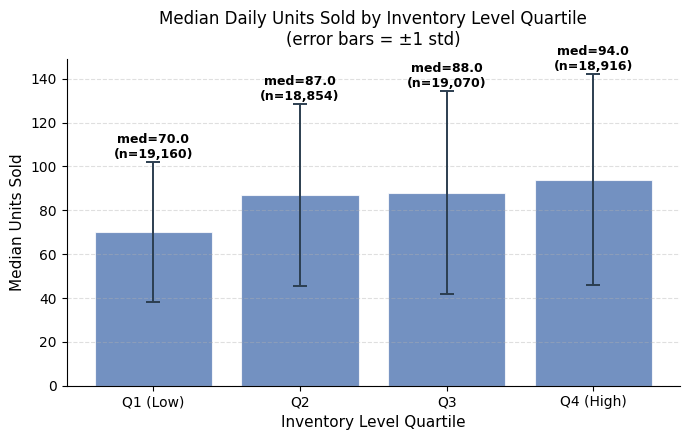

✅ Saved → outputs/fig1_inventory_level_vs_units_sold.png
  Q1 (Low): median=70.00, std=31.99, n=19,160
  Q2: median=87.00, std=41.34, n=18,854
  Q3: median=88.00, std=46.26, n=19,070
  Q4 (High): median=94.00, std=48.05, n=18,916


In [7]:

# ── Fig. 1 (Paper) — Inventory Level quartile bins vs. median Units Sold ──────
# Used in Section II.B (EDA) to motivate why exogenous-aware models (HGB) are
# needed: Inventory Level is the #1 permutation-importance feature (0.242) and
# Chronos (univariate) has no access to it.

import matplotlib.pyplot as plt
import os

_df_a = df[["Inventory Level", "Units Sold"]].copy().dropna()
_df_a["IL_bin"] = pd.qcut(_df_a["Inventory Level"], q=4,
                           labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])
_grp  = _df_a.groupby("IL_bin", observed=True)["Units Sold"]
_meds = _grp.median()
_stds = _grp.std()
_ns   = _grp.count()

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(_meds.index, _meds.values, color="#4C72B0", alpha=0.78,
              edgecolor="white", linewidth=0.8)
ax.errorbar(_meds.index, _meds.values, yerr=_stds.values,
            fmt="none", color="#2c3e50", capsize=5, linewidth=1.4, capthick=1.4)

for bar, v, n in zip(bars, _meds.values, _ns.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + _stds.values[list(_meds.values).index(v)] + 0.5,
            f"med={v:.1f}\n(n={n:,})", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xlabel("Inventory Level Quartile", fontsize=11)
ax.set_ylabel("Median Units Sold", fontsize=11)
ax.set_title("Median Daily Units Sold by Inventory Level Quartile\n"
             "(error bars = ±1 std)", fontsize=12, pad=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

os.makedirs(OUTPUT_DIR, exist_ok=True)
fig_path = os.path.join(OUTPUT_DIR, "fig1_inventory_level_vs_units_sold.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {fig_path}")
for q, med, std, n in zip(_meds.index, _meds.values, _stds.values, _ns.values):
    print(f"  {q}: median={med:.2f}, std={std:.2f}, n={n:,}")


# Phase 4 — Time-based split

| Question | Answer |
|---|---|
| **Target variable** | `Units Sold` — số lượng bán mỗi ngày, per chuỗi (Store × Product). |
| **Data frequency** | **Daily**. |
| **Forecast horizon** | **H = 7** (`HORIZON_DAYS`). |
| **Forecast origin** | **Validation:** sau train → `TRAIN_END` (`2023-06-30`). **Test:** sau train+val → `VAL_END` (`2023-10-31`). |
| **One-step vs multi-step** | **Multi-step:** dự báo đồng thời $\hat{y}_{t+1},\ldots,\hat{y}_{t+H}$ |


In [8]:
# Time-based split (independent from forecasting horizon)
HORIZON_DAYS = 7   # forecasting horizon — all models predict H=7 steps 
FORECAST_GAP = 0   # khoảng ngày giữa cuối train và đầu val; 0 = không cố ý để trống
                   # (per-series lag features never cross the split boundary)
TRAIN_END = pd.Timestamp("2023-06-30")
VAL_END = pd.Timestamp("2023-10-31")

# Ensure Date is datetime even if prior preprocessing cell was not rerun
if not pd.api.types.is_datetime64_any_dtype(df["Date"]):
    df["Date"] = pd.to_datetime(df["Date"])

train_df = df[df["Date"] <= TRAIN_END].copy()
val_df = df[(df["Date"] > TRAIN_END) & (df["Date"] <= VAL_END)].copy()
test_df = df[df["Date"] > VAL_END].copy()

print(f"Forecast horizon (H): {HORIZON_DAYS} days")
print(f"Train end: {TRAIN_END.date()}")
print(f"Validation: {(TRAIN_END + pd.Timedelta(days=1)).date()} -> {VAL_END.date()}")
print(f"Test: > {VAL_END.date()}")
len(train_df), len(val_df), len(test_df)


Forecast horizon (H): 7 days
Train end: 2023-06-30
Validation: 2023-07-01 -> 2023-10-31
Test: > 2023-10-31


(54600, 12300, 9100)

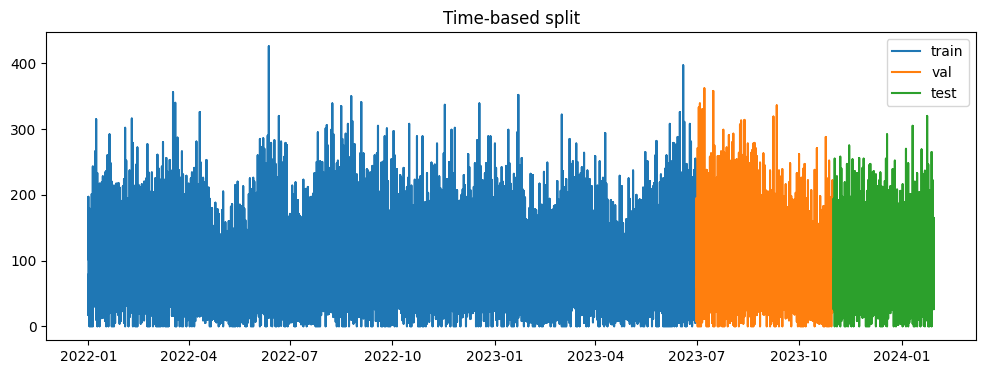

In [9]:
plt.figure(figsize=(12,4))
plt.plot(train_df["Date"], train_df["Units Sold"], label="train")
plt.plot(val_df["Date"], val_df["Units Sold"], label="val")
plt.plot(test_df["Date"], test_df["Units Sold"], label="test")
plt.legend()
plt.title("Time-based split")
plt.show()


## Phase 5 — Evaluation metrics

| Metric | Công thức | Khi dùng |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum\|y-\hat{y}\|$ | Metric chính — dễ hiểu, robust |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y-\hat{y})^2}$ | Phạt lỗi lớn nặng hơn MAE; ưu tiên khi peak demand quan trọng |
| **sMAPE** | $\frac{200}{n}\sum\frac{\|y-\hat{y}\|}{\|y\|+\|\hat{y}\|+\varepsilon}$ | Thay MAPE — bounded [0,200%], không bị phân kỳ khi y=0 |

> ⚠️ **Không dùng MAPE thuần túy** — khi `Units Sold = 0`, MAPE → ∞. Dataset này có nhiều ngày zero-sales → dùng sMAPE thay thế.


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def smape(y_true, y_pred, eps=1e-8):
    """Symmetric MAPE — bounded [0, 200%], handles y=0 gracefully.
    Replaces naive MAPE which diverges when Units Sold = 0.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(200 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + eps)))

def eval_forecast(y_true, y_pred, prefix="val", y_train=None):
    return {
        f"{prefix}_MAE":   float(mean_absolute_error(y_true, y_pred)),
        f"{prefix}_RMSE":  rmse(y_true, y_pred),
        f"{prefix}_sMAPE": smape(y_true, y_pred),   # bounded [0,200%], replaces MAPE
    }


# Phase 6 — Baseline models

- Group 1 — Classical baselines: Naive · Seasonal naive · ARIMA · SARIMAX · ETS · 
-  Group 2 — ML-based: Ridge regression · HistGradientBoosting · LSTM univariate · LSTM multivariate, Prophet
- Group 3 — Pre-trained foundation model: Chronos-Bolt-Small (zero-shot, univariate)


## Group 1 — Naive forecast

Naive:
- dự báo ngày tiếp theo bằng giá trị gần nhất

Đây là baseline cực quan trọng trong forecasting.
Nếu mô hình phức tạp không thắng naive rõ ràng, có thể có vấn đề.


In [11]:
# Forecast val using last observed point from train, recursively as a flat forecast
last_train_value = train_df["Units Sold"].iloc[-1]
val_pred_naive = np.repeat(last_train_value, len(val_df))

eval_forecast(val_df["Units Sold"], val_pred_naive, prefix="val")


{'val_MAE': 35.027723577235776,
 'val_RMSE': 46.558625514034425,
 'val_sMAPE': 40.39816056245148}

## Group 1 — Seasonal naive forecast

Với daily data có weekly seasonality:
- dự báo hôm nay bằng giá trị của 7 ngày trước

Seasonal naive thường là baseline rất mạnh.


In [12]:
def seasonal_naive_predict(history_values, horizon, season_length=7):
    history_values = list(history_values)
    preds = []
    for i in range(horizon):
        preds.append(history_values[-season_length + (i % season_length)])
    return np.array(preds)

val_pred_snaive = seasonal_naive_predict(train_df["Units Sold"].values, len(val_df), season_length=7)
eval_forecast(val_df["Units Sold"], val_pred_snaive, prefix="val")


{'val_MAE': 45.40471544715447,
 'val_RMSE': 59.39119449665782,
 'val_sMAPE': 58.120835320580525}

## Group 1 — ARIMA and SARIMAX

Trong phần này ta thêm **ARIMA (non-seasonal)** và giữ **SARIMAX (seasonal)** để so sánh baseline cổ điển công bằng.

- ARIMA: phù hợp chuỗi đơn biến, cấu trúc đơn giản
- SARIMAX: thêm seasonality tuần và cấu trúc linh hoạt hơn

> Practice: bắt đầu từ baseline cổ điển trước khi qua model phức tạp.


In [13]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- ARIMA (non-seasonal) baseline ---
arima = ARIMA(
    train_df["Units Sold"],
    order=(2,1,2)
)
arima_fit = arima.fit()
val_pred_arima = arima_fit.forecast(steps=len(val_df))

arima_val_metrics = eval_forecast(val_df["Units Sold"], val_pred_arima, prefix="val")
print('ARIMA baseline metrics:')
print(arima_val_metrics)

# --- SARIMAX seasonal baseline ---
sarimax = SARIMAX(
    train_df["Units Sold"],
    order=(2,1,2),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax.fit(disp=False)
val_pred_sarimax = sarimax_fit.forecast(steps=len(val_df))

sarimax_val_metrics = eval_forecast(val_df["Units Sold"], val_pred_sarimax, prefix="val")
print('SARIMAX baseline metrics:')
print(sarimax_val_metrics)

ARIMA baseline metrics:
{'val_MAE': 35.32002259768432, 'val_RMSE': 45.69781881982683, 'val_sMAPE': 40.431360550864134}


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX baseline metrics:
{'val_MAE': 35.31660598733458, 'val_RMSE': 45.697667073354836, 'val_sMAPE': 40.428687918561614}


## Group 1 — ETS (Exponential Smoothing)

ETS là baseline thống kê cổ điển mạnh cho chuỗi có level/trend/seasonality.

- Dễ dùng và chạy nhanh hơn nhiều mô hình phức tạp
- Là baseline tốt để so sánh trước khi dùng ML/deep learning

> Practice: luôn thêm baseline cổ điển mạnh để kiểm tra pipeline có thật sự tốt hơn không.


In [14]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ETS additive trend + additive weekly seasonality
ets = ExponentialSmoothing(
    train_df["Units Sold"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit(optimized=True)

val_pred_ets = ets.forecast(len(val_df))

ets_val_metrics = eval_forecast(
    val_df["Units Sold"],
    val_pred_ets,
    prefix="val")
print("ETS baseline metrics:")
print(ets_val_metrics)


ETS baseline metrics:
{'val_MAE': 35.416337953839175, 'val_RMSE': 45.9320491981215, 'val_sMAPE': 40.53231533472983}


## Group 1 — Prophet

Prophet là baseline cổ điển mạnh, dễ triển khai cho chuỗi có trend + seasonality.

- Tự động mô hình hóa trend/seasonality
- Hữu ích trong bối cảnh business forecasting

> Practice: so sánh Prophet cùng cách cắt train/val/test với các baseline để công bằng.


In [15]:
import logging
import contextlib
from prophet import Prophet

# Suppress Prophet / Stan verbose output
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

@contextlib.contextmanager
def _suppress_prophet_output():
    """Redirect prophet's stdout/stderr during fitting."""
    import io, sys
    old_stdout, old_stderr = sys.stdout, sys.stderr
    sys.stdout = sys.stderr = io.StringIO()
    try:
        yield
    finally:
        sys.stdout, sys.stderr = old_stdout, old_stderr

def prophet_fn(train_dates, train_values, horizon):
    """Fit Prophet on training series and forecast `horizon` steps ahead.
    Returns np.array of length `horizon`.
    """
    df_fit = pd.DataFrame({
        'ds': pd.to_datetime(train_dates),
        'y':  train_values.astype(float),
    })
    # Drop any NaN rows (Prophet sẽ báo lỗi nếu y có NaN)
    df_fit = df_fit.dropna()
    if len(df_fit) < 14:
        raise ValueError(f"Không đủ dữ liệu sau khi dropna: {len(df_fit)} rows")

    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=False,
    )
    with _suppress_prophet_output():
        model.fit(df_fit)

    # make_future_dataframe: dùng pd.Timedelta để tránh deprecation warning với freq='D'
    last_date = df_fit["ds"].max()
    future_dates = pd.DataFrame({
        "ds": [last_date + pd.Timedelta(days=i) for i in range(1, horizon + 1)]
    })
    forecast = model.predict(future_dates)
    return np.clip(forecast["yhat"].values, 0, None)

# ── Per-series evaluation: H=7 từ một forecast origin  ───────────
prophet_series_records = []
prophet_scores = {'val_MAE': [], 'val_RMSE': [], 'val_sMAPE': []}
prophet_errors = []

for (store, product), grp in df.groupby(['Store ID', 'Product ID']):
    s = grp.set_index('Date')['Units Sold'].sort_index()
    s.index = pd.to_datetime(s.index)

    train_s = s[s.index <= TRAIN_END]
    val_s   = s[(s.index > TRAIN_END) & (s.index <= VAL_END)]

    # Cần đủ training data và ít nhất HORIZON_DAYS val rows
    if len(train_s) < 14 or len(val_s) < HORIZON_DAYS:
        continue

    try:
        # Forecast H=7 
        y_pred = prophet_fn(train_s.index, train_s.values, HORIZON_DAYS)
        y_true = val_s.values[:HORIZON_DAYS].astype(float)  # lấy 7 ngày đầu val
        metrics = eval_forecast(y_true, y_pred, prefix='val', y_train=train_s.values)
    except Exception as e:
        prophet_errors.append({'store': store, 'product': product, 'error': str(e)})
        continue

    for k in prophet_scores:
        prophet_scores[k].append(metrics[k])

    prophet_series_records.append({
        'store': store, 'product': product,
        **{k: round(float(v), 4) for k, v in metrics.items()},
    })

prophet_details_df = pd.DataFrame(prophet_series_records)

prophet_val_metrics = {k: float(np.nanmean(v)) for k, v in prophet_scores.items()}
print(f'Prophet per-series (H={HORIZON_DAYS}): {len(prophet_series_records)} / 100 series hoàn thành')
if prophet_errors:
    print(f'  ⚠️  {len(prophet_errors)} series bị lỗi:')
    for e in prophet_errors[:3]:
        print(f"     Store={e['store']} Product={e['product']}: {e['error']}")
print('Prophet val metrics (trung bình qua các series):')
for k, v in prophet_val_metrics.items():
    print(f'  {k}: {v:.4f}')
print(f'Chi tiết từng series: prophet_details_df ({len(prophet_series_records)} rows)')


Prophet per-series (H=7): 100 / 100 series hoàn thành
Prophet val metrics (trung bình qua các series):
  val_MAE: 35.7392
  val_RMSE: 44.5651
  val_sMAPE: 37.8408
Chi tiết từng series: prophet_details_df (100 rows)


### Quy trình Feature Engineering

**Ý tưởng chính:** biến bài toán time series thành bài toán supervised learning bằng cách tạo các đặc trưng từ lịch sử chuỗi.


| Nhóm | Đặc trưng | Vai trò |
|---|---|---|
| **Lag** | `lag_1`, `lag_2`, `lag_3`, `lag_7`, `lag_14`, `lag_28` | Giá trị quá khứ gần — nắm bắt autocorrelation |
| **Rolling mean** | `roll_mean_7`, `roll_mean_14`, `roll_mean_28` | Xu hướng ngắn/trung/dài hạn |
| **Rolling std** | `roll_std_7`, `roll_std_14`, `roll_std_28` | Biến động (volatility) của chuỗi |
| **Calendar** | `dayofweek`, `month`, `dayofyear` | Seasonal patterns tuần/năm |
| **Exogenous** | `Price`, `Discount`, `Promotion`, `Competitor Pricing`, `Epidemic` | Tín hiệu kinh doanh bên ngoài |

> **Leakage prevention:** tất cả lag/rolling features dùng `.shift(1)` trước khi tính → chỉ dùng thông tin tại $t-1$ để dự báo $t$.

> **Biến bị loại khỏi feature set:** `Demand`, `Units Ordered` — theo yêu cầu nghiệp vụ.

**Tổng:** 20 features cho mỗi mô hình ML tabular.


In [16]:
def make_ts_features(df_in):
    df_feat = df_in.copy()
    df_feat = df_feat.sort_values("Date").reset_index(drop=True)
    df_feat["Date"] = pd.to_datetime(df_feat["Date"])
    # Lag features
    for lag in [1, 2, 3, 7, 14, 28]:
        df_feat[f"lag_{lag}"] = df_feat["Units Sold"].shift(lag)

    # Rolling features
    for window in [7, 14, 28]:
        df_feat[f"roll_mean_{window}"] = df_feat["Units Sold"].shift(1).rolling(window).mean()
        df_feat[f"roll_std_{window}"] = df_feat["Units Sold"].shift(1).rolling(window).std()

    # Calendar features
    df_feat["dayofweek"] = df_feat["Date"].dt.dayofweek
    df_feat["month"] = df_feat["Date"].dt.month
    df_feat["dayofyear"] = df_feat["Date"].dt.dayofyear

    return df_feat

df_feat = make_ts_features(df)
df_feat.head(10)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_28,roll_std_28,dayofweek,month,dayofyear
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
1,2022-01-01,S004,P0013,Groceries,West,136,104,385,20.24,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
2,2022-01-01,S004,P0012,Electronics,West,111,111,113,118.15,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
3,2022-01-01,S004,P0011,Clothing,West,195,60,293,52.89,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
4,2022-01-01,S004,P0010,Groceries,West,223,120,597,30.02,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
5,2022-01-01,S004,P0009,Clothing,West,206,106,299,110.47,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
6,2022-01-01,S004,P0008,Furniture,West,281,59,0,100.64,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
7,2022-01-01,S004,P0007,Groceries,West,185,43,253,24.34,5,...,NaN,94.571429,24.670206,NaN,NaN,NaN,NaN,5,1,1
8,2022-01-01,S004,P0006,Groceries,West,206,48,162,35.33,0,...,NaN,86.142857,30.980793,NaN,NaN,NaN,NaN,5,1,1
9,2022-01-01,S004,P0005,Clothing,West,289,197,0,89.23,10,...,NaN,78.142857,32.779204,NaN,NaN,NaN,NaN,5,1,1


In [17]:
# Split again after feature generation (same full train/val/test windows)
train_feat = df_feat[df_feat["Date"] <= TRAIN_END].copy()
val_feat = df_feat[(df_feat["Date"] > TRAIN_END) & (df_feat["Date"] <= VAL_END)].copy()
test_feat = df_feat[df_feat["Date"] > VAL_END].copy()

feature_cols = [c for c in train_feat.columns if c not in ["Date", "Units Sold", "Store ID", "Product ID", "Category", "Region", "Weather Condition", "Seasonality", "Demand", "Units Ordered"]]

train_feat = train_feat.dropna().reset_index(drop=True)
val_feat = val_feat.dropna().reset_index(drop=True)
test_feat = test_feat.dropna().reset_index(drop=True)

X_train = train_feat[feature_cols]
y_train = train_feat["Units Sold"]
X_val = val_feat[feature_cols]
y_val = val_feat["Units Sold"]
X_test = test_feat[feature_cols]
y_test = test_feat["Units Sold"]

X_train.shape, X_val.shape, X_test.shape


((54572, 21), (12300, 21), (9100, 21))

## Group 2 — Ridge regression with Lag Features

**Ridge Regression** là baseline ML-based đơn giản và minh bạch nhất:

- **Dễ giải thích:** hệ số $w_i$ cho biết đóng góp của từng lag/feature
- **Tránh overfitting** bằng regularization L2: $\min \|Xw - y\|^2_2 + \alpha\|w\|^2_2$
- **Pipeline:** `SimpleImputer → StandardScaler → Ridge(α=1.0)`

**Điểm quan trọng:**
- **Scaler fit on train only** → không leakage vào val/test
- **Imputer** xử lý NaN trong lag features (các dòng đầu không có đủ lookback)
- Đây là `Model A` trong bộ so sánh — dùng làm **ceiling cho linear model**

**Nhược điểm:** không nắm bắt được quan hệ phi tuyến giữa lag features và target. HGB sẽ giải quyết điều này.


In [18]:

_lag_cols  = [c for c in feature_cols if c.startswith("lag_")]
_roll_cols = [c for c in feature_cols if c.startswith("roll_")]
_cal_cols  = ["dayofweek", "month", "dayofyear"]
_exog_cols = [c for c in feature_cols if c not in set(_lag_cols + _roll_cols + _cal_cols)]

if _exog_cols:
    print(f"Exogenous features (known-future): {_exog_cols}")
else:
    print("No exogenous features detected — purely lag/rolling/calendar.")


def evaluate_rolling_horizon(model, context_end, df_all, feat_cols, prefix, horizon=HORIZON_DAYS):
    """Per-series H=7 recursive prediction without oracle lags.

    Parameters
    ----------
    model       : fitted sklearn model / Pipeline
    context_end : Timestamp — forecast origin (no data beyond this used)
    df_all      : full DataFrame (provides exogenous values for forecast window)
    feat_cols   : ordered list of feature column names the model expects
    prefix      : 'val' | 'test' | 'fold'
    """
    lag_keys  = [c for c in feat_cols if c.startswith("lag_")]
    roll_keys = [c for c in feat_cols if c.startswith("roll_")]
    exog_keys = [c for c in feat_cols if c not in set(lag_keys + roll_keys + _cal_cols)]

    scores  = {f"{prefix}_MAE": [], f"{prefix}_RMSE": [],
               f"{prefix}_sMAPE": []}
    records = []
    skipped = 0

    for (store, product), grp in df_all.groupby(["Store ID", "Product ID"]):
        grp = grp.sort_values("Date").copy()
        grp["Date"] = pd.to_datetime(grp["Date"])

        hist_grp   = grp[grp["Date"] <= pd.Timestamp(context_end)]
        future_grp = grp[grp["Date"] >  pd.Timestamp(context_end)].head(horizon)

        if len(hist_grp) < 28 or len(future_grp) < horizon:
            skipped += 1
            continue

        y_hist = list(hist_grp["Units Sold"].values.astype(float))
        y_true = future_grp["Units Sold"].values[:horizon].astype(float)

        preds = []
        for h in range(horizon):
            row       = future_grp.iloc[h]
            pred_date = pd.Timestamp(row["Date"])
            y_all     = np.array(y_hist + preds)   # history + recursive preds

            feat = {}

            # Lag features from available history (no oracle)
            for lag_col in lag_keys:
                lag = int(lag_col.split("_")[1])
                feat[lag_col] = float(y_all[-lag]) if len(y_all) >= lag else np.nan

            # Rolling features
            for roll_col in roll_keys:
                w   = int(roll_col.split("_")[-1])
                win = y_all[-w:] if len(y_all) >= w else y_all
                if "std" in roll_col:
                    feat[roll_col] = float(np.nanstd(win))  if len(win) > 1 else 0.0
                else:
                    feat[roll_col] = float(np.nanmean(win))

            # Calendar features (always known)
            feat["dayofweek"] = pred_date.dayofweek
            feat["month"]     = pred_date.month
            feat["dayofyear"] = pred_date.dayofyear

            # Exogenous: actual values from dataset (known-future externals)
            for col in exog_keys:
                feat[col] = float(row[col]) if col in row.index else 0.0

            feat_arr = np.array([[feat.get(c, 0.0) for c in feat_cols]])
            pred = float(np.clip(model.predict(feat_arr)[0], 0, None))
            preds.append(pred)

        y_pred = np.array(preds)
        m = eval_forecast(y_true, y_pred, prefix=prefix, y_train=np.array(y_hist))
        for k in scores:
            scores[k].append(m[k])
        records.append({
            "store": store, "product": product,
            **{k: round(float(m[k]), 4) for k in m}
        })

    agg = {k: float(np.nanmean(v)) for k, v in scores.items()}
    print(f"  [{prefix}] {len(records)} series evaluated, {skipped} skipped")
    return agg, records

def build_hgb_horizon_predictions(model, context_end, df_all, feat_cols, horizon=HORIZON_DAYS):
    lag_keys  = [c for c in feat_cols if c.startswith("lag_")]
    roll_keys = [c for c in feat_cols if c.startswith("roll_")]
    exog_keys = [c for c in feat_cols if c not in set(lag_keys + roll_keys + _cal_cols)]
    result    = {}

    for (store, product), grp in df_all.groupby(["Store ID", "Product ID"]):
        grp = grp.sort_values("Date").copy()
        grp["Date"] = pd.to_datetime(grp["Date"])
        hist_grp   = grp[grp["Date"] <= pd.Timestamp(context_end)]
        future_grp = grp[grp["Date"] >  pd.Timestamp(context_end)].head(horizon)

        if len(hist_grp) < 28 or len(future_grp) < horizon:
            continue

        y_hist = list(hist_grp["Units Sold"].values.astype(float))
        preds  = []

        for h in range(horizon):
            row       = future_grp.iloc[h]
            pred_date = pd.Timestamp(row["Date"])
            y_all     = np.array(y_hist + preds)

            feat = {}
            for lag_col in lag_keys:
                lag = int(lag_col.split("_")[1])
                feat[lag_col] = float(y_all[-lag]) if len(y_all) >= lag else np.nan
            for roll_col in roll_keys:
                w   = int(roll_col.split("_")[-1])
                win = y_all[-w:] if len(y_all) >= w else y_all
                feat[roll_col] = (float(np.nanstd(win)) if "std" in roll_col and len(win) > 1
                                  else float(np.nanmean(win)))
            feat["dayofweek"] = pred_date.dayofweek
            feat["month"]     = pred_date.month
            feat["dayofyear"] = pred_date.dayofyear
            for col in exog_keys:
                feat[col] = float(row[col]) if col in row.index else 0.0

            feat_arr = np.array([[feat.get(c, 0.0) for c in feat_cols]])
            pred = float(np.clip(model.predict(feat_arr)[0], 0, None))
            preds.append(pred)

        result[(store, product)] = np.array(preds)

    return result

Exogenous features (known-future): ['Inventory Level', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Epidemic']


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

ridge_ts = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_ts.fit(X_train, y_train)
val_pred_ridge = ridge_ts.predict(X_val)

eval_forecast(y_val, val_pred_ridge, prefix="val")

ridge_val_c_metrics, _ = evaluate_rolling_horizon(ridge_ts, TRAIN_END, df, feature_cols, prefix="val")


  [val] 100 series evaluated, 0 skipped


## Group 2 — HistGradientBoosting với Lag Features

**HistGradientBoosting (HGB)** là mô hình tree-based mạnh nhất trong scikit-learn:

| Đặc điểm | Chi tiết |
|---|---|
| Thuật toán | Histogram-based gradient boosting (tương tự LightGBM) |
| Xử lý NaN | **Natively** — không cần imputer |
| Tốc độ | Nhanh hơn GradientBoosting ~10× nhờ histogram bins |
| Hyperparameters | `max_depth=5`, `learning_rate=0.05`, `random_state=SEED` |

**Tại sao HGB mạnh hơn Ridge cho bài toán này:**
- Nắm bắt quan hệ phi tuyến: `lag_7 × Promotion` (doanh số tăng đột biến khi khuyến mãi cuối tuần)
- Xử lý interaction giữa calendar features và exogenous features
- Robust với outlier và zero-sales days

> **Evaluation:** one-step-ahead trên toàn tập validation (~12,300 dòng) sử dụng real observed lags (oracle setting). HGB là model benchmark chính của notebook.


In [20]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_ts = HistGradientBoostingRegressor(
    random_state=RANDOM_SEED,
    max_depth=5,
    learning_rate=0.05
)

hgb_ts.fit(X_train, y_train)
val_pred_hgb = hgb_ts.predict(X_val)

eval_forecast(y_val, val_pred_hgb, prefix="val")

hgb_val_c_metrics, _ = evaluate_rolling_horizon(hgb_ts, TRAIN_END, df, feature_cols, prefix="val")


  [val] 100 series evaluated, 0 skipped


## Group 2 — LSTM univariate

**LSTM (Long Short-Term Memory)** là kiến trúc deep learning cơ bản cho time series:

```
Input: [y_{t-30}, ..., y_{t-1}]  (lookback = 30 ngày)
  → LSTM(hidden=64) → Dropout(0.2) → Linear(1)
  → ŷ_t
```
- **Evaluation:** rolling one-step-ahead trên chuỗi daily — mỗi bước chỉ dùng quan sát **trước ngày target**; sau đó ŷ được **nhân bản theo `Date`** cho toàn bộ panel để so sánh metric với các baseline khác.

> **Mục đích:** kiểm tra xem kiến trúc sequence model cơ bản có cạnh tranh được với tabular ML không. Kết quả thường cho thấy HGB mạnh hơn LSTM univariate trong bài toán bán lẻ có exogenous signal.


In [21]:
LOOKBACK_LSTM = 30
VERBOSE_WINDOWS = True
MAX_VERBOSE_STEPS = 8
EPOCHS_LSTM = 20

def log_window(tag, step, total_steps, history_dates, target_date, lookback, enabled=True, max_steps=8):
    if not enabled:
        return
    if not (step < max_steps or step == total_steps - 1):
        return
    start_idx = max(0, len(history_dates) - lookback)
    win_start = pd.Timestamp(history_dates[start_idx]).date()
    win_end = pd.Timestamp(history_dates[-1]).date()
    tgt = pd.Timestamp(target_date).date()
    print(f"[{tag} step={step:03d}] context_window: {win_start} -> {win_end} | target: {tgt}")

try:
    import torch
    import torch.nn as nn
    torch.manual_seed(RANDOM_SEED)

    class LSTMUni(nn.Module):
        def __init__(self, hidden_size=64):
            super().__init__()
            self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
            self.dropout = nn.Dropout(0.2)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            return self.fc(out).squeeze(-1)

    # Daily aggregate: một chuỗi univariate thật — mean Units Sold theo ngày (không dùng thứ tự hàng panel làm "thời gian").
    ts_daily = df.groupby("Date")["Units Sold"].mean().sort_index()
    ts_daily.index = pd.to_datetime(ts_daily.index)

    train_series = ts_daily.loc[ts_daily.index <= TRAIN_END].astype(float).values
    val_series = ts_daily.loc[(ts_daily.index > TRAIN_END) & (ts_daily.index <= VAL_END)].astype(float).values
    train_dates = ts_daily.loc[ts_daily.index <= TRAIN_END].index.values
    val_dates = ts_daily.loc[(ts_daily.index > TRAIN_END) & (ts_daily.index <= VAL_END)].index.values

    # PRACTICE: fit scaler on train only (avoid preprocessing leakage)
    mu = float(train_series.mean())
    sd = float(train_series.std()) + 1e-8
    train_norm = (train_series - mu) / sd

    X_lstm, y_lstm = [], []
    for i in range(len(train_norm) - LOOKBACK_LSTM):
        X_lstm.append(train_norm[i:i+LOOKBACK_LSTM])
        y_lstm.append(train_norm[i+LOOKBACK_LSTM])

    X_lstm = torch.tensor(np.array(X_lstm), dtype=torch.float32).unsqueeze(-1)
    y_lstm = torch.tensor(np.array(y_lstm), dtype=torch.float32)

    lstm_uni = LSTMUni(hidden_size=64)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(lstm_uni.parameters(), lr=1e-3)

    lstm_uni.train()
    for _ in range(EPOCHS_LSTM):
        optimizer.zero_grad()
        pred = lstm_uni(X_lstm)
        loss = criterion(pred, y_lstm)
        loss.backward()
        optimizer.step()

    lstm_uni.eval()
    val_pred_daily = []
    for t in range(len(val_series)):
        # History chỉ gồm train + các ngày val đã quan sát trước ngày dự báo (rolling thực, một bước / ngày).
        history = np.concatenate([train_series, val_series[:t]])
        history_dates = np.concatenate([train_dates, val_dates[:t]])
        history_norm = (history - mu) / sd

        if len(history_norm) < LOOKBACK_LSTM:
            pad = np.repeat(history_norm[0] if len(history_norm) else 0.0, LOOKBACK_LSTM - len(history_norm))
            context = np.concatenate([pad, history_norm])
        else:
            context = history_norm[-LOOKBACK_LSTM:]

        log_window(
            tag="VAL",
            step=t,
            total_steps=len(val_series),
            history_dates=history_dates,
            target_date=val_dates[t],
            lookback=LOOKBACK_LSTM,
            enabled=VERBOSE_WINDOWS,
            max_steps=MAX_VERBOSE_STEPS,
        )

        x = torch.tensor(context.reshape(1, LOOKBACK_LSTM, 1), dtype=torch.float32)
        with torch.no_grad():
            yhat_norm = float(lstm_uni(x).item())
        val_pred_daily.append(yhat_norm * sd + mu)

    val_pred_daily = np.array(val_pred_daily)

    # Ánh xạ ŷ theo ngày sang từng hàng panel val_df (metrics đồng nhất các baseline khác).
    _lstm_val_lut = pd.DataFrame({"Date": pd.to_datetime(val_dates), "_p": val_pred_daily})
    val_pred_lstm_uni = (
        val_df[["Date"]]
        .assign(Date=lambda x: pd.to_datetime(x["Date"]))
        .merge(_lstm_val_lut, on="Date", how="left")["_p"]
        .values
    )

    print("LSTM-univariate baseline metrics:")
    eval_forecast(val_df["Units Sold"], val_pred_lstm_uni, prefix="val", y_train=train_df["Units Sold"])

except Exception as e:
    print("LSTM unavailable, fallback to naive. Reason:", e)
    val_pred_lstm_uni = np.repeat(train_df["Units Sold"].iloc[-1], len(val_df))
    eval_forecast(val_df["Units Sold"], val_pred_lstm_uni, prefix="val", y_train=train_df["Units Sold"])


[VAL step=000] context_window: 2023-06-01 -> 2023-06-30 | target: 2023-07-01
[VAL step=001] context_window: 2023-06-02 -> 2023-07-01 | target: 2023-07-02
[VAL step=002] context_window: 2023-06-03 -> 2023-07-02 | target: 2023-07-03
[VAL step=003] context_window: 2023-06-04 -> 2023-07-03 | target: 2023-07-04
[VAL step=004] context_window: 2023-06-05 -> 2023-07-04 | target: 2023-07-05
[VAL step=005] context_window: 2023-06-06 -> 2023-07-05 | target: 2023-07-06
[VAL step=006] context_window: 2023-06-07 -> 2023-07-06 | target: 2023-07-07
[VAL step=007] context_window: 2023-06-08 -> 2023-07-07 | target: 2023-07-08
[VAL step=122] context_window: 2023-10-01 -> 2023-10-30 | target: 2023-10-31
LSTM-univariate baseline metrics:


## Group 2 — LSTM multivariate — daily aggregate (một chuỗi ngày)

**Giống LSTM Univariate (§11):** một **chuỗi daily** duy nhất — không lặp vòng theo từng `(Store, Product)` nên chạy nhanh.

**Khác uni:** mỗi ngày vector đầu vào là **`feature_cols` đã gộp**: với mỗi `Date`, lấy **mean** trên toàn panel của `Units Sold` (target aggregate) và **mean** từng feature số trong `feature_cols`. Nhịp rolling one-step và **broadcast ŷ theo `Date`** xuống các hàng panel giữ nguyên như §11.

In [22]:
try:
    LOOKBACK_LSTM_MULTI = LOOKBACK_LSTM  # đồng bộ với LSTM univariate (§11)
except NameError:
    LOOKBACK_LSTM_MULTI = 30
EPOCHS_LSTM_MULTI = 20
BATCH_LSTM_MULTI = 512

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler

    torch.manual_seed(RANDOM_SEED)

    class LSTMMulti(nn.Module):
        def __init__(self, n_feat, hidden_size=64):
            super().__init__()
            self.lstm = nn.LSTM(input_size=n_feat, hidden_size=hidden_size, num_layers=1, batch_first=True)
            self.dropout = nn.Dropout(0.2)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            return self.fc(out).squeeze(-1)

    # ── Daily aggregate: một chuỗi ngày — mean(Unit Sold), mean(từng feature)/ngày (không lặp từng series)
    _daily_lm = (
        df_feat.groupby(pd.to_datetime(df_feat["Date"]).dt.normalize())
        .agg({"Units Sold": "mean", **{c: "mean" for c in feature_cols}})
        .sort_index()
    )
    _daily_lm.index = pd.to_datetime(_daily_lm.index)

    train_dlm = _daily_lm.loc[_daily_lm.index <= TRAIN_END].copy()
    val_dlm = _daily_lm.loc[(_daily_lm.index > TRAIN_END) & (_daily_lm.index <= VAL_END)].copy()

    # Target scale giống §11 LSTM uni: học trên y chuẩn hóa (X đã StandardScaler — tránh scale mismatch)
    mu_y_lm = float(train_dlm["Units Sold"].mean())
    sd_y_lm = float(train_dlm["Units Sold"].std()) + 1e-8

    _imp_lm = SimpleImputer(strategy="median")
    _sc_lm = StandardScaler()
    _imp_lm.fit(train_dlm[feature_cols].values)
    _sc_lm.fit(_imp_lm.transform(train_dlm[feature_cols].values))

    def _lm_X_from_hist(hist: pd.DataFrame):
        """hist: daily rows (chronological), columns include feature_cols."""
        raw = hist[feature_cols].values
        X = _sc_lm.transform(_imp_lm.transform(raw)).astype(np.float32)
        if len(X) < LOOKBACK_LSTM_MULTI:
            pad = np.repeat(X[0:1], LOOKBACK_LSTM_MULTI - len(X), axis=0)
            X = np.vstack([pad, X])
        else:
            X = X[-LOOKBACK_LSTM_MULTI:]
        return X

    _nfeat_lm = len(feature_cols)
    _Xs, _ys = [], []
    for _i in range(LOOKBACK_LSTM_MULTI, len(train_dlm)):
        _win = train_dlm.iloc[_i - LOOKBACK_LSTM_MULTI : _i]
        _Xs.append(_lm_X_from_hist(_win))
        _ys.append((float(train_dlm.iloc[_i]["Units Sold"]) - mu_y_lm) / sd_y_lm)

    _Xtr_m = np.stack(_Xs, axis=0)
    _ytr_m = np.array(_ys, dtype=np.float32)
    _ds_m = TensorDataset(torch.from_numpy(_Xtr_m), torch.from_numpy(_ytr_m))
    _dl_m = DataLoader(_ds_m, batch_size=BATCH_LSTM_MULTI, shuffle=True)

    lstm_multi = LSTMMulti(n_feat=_nfeat_lm)
    _crit_m = nn.MSELoss()
    _opt_m = torch.optim.Adam(lstm_multi.parameters(), lr=1e-3)

    lstm_multi.train()
    for _ in range(EPOCHS_LSTM_MULTI):
        for xb, yb in _dl_m:
            _opt_m.zero_grad()
            pr = lstm_multi(xb)
            loss = _crit_m(pr, yb)
            loss.backward()
            _opt_m.step()

    lstm_multi.eval()
    val_pred_daily_lm = []
    val_dates_lm = val_dlm.index.values
    with torch.no_grad():
        for _t in range(len(val_dlm)):
            _hist = pd.concat([train_dlm, val_dlm.iloc[:_t]])
            x = torch.from_numpy(_lm_X_from_hist(_hist).reshape(1, LOOKBACK_LSTM_MULTI, _nfeat_lm))
            _yh = float(lstm_multi(x).item()) * sd_y_lm + mu_y_lm
            val_pred_daily_lm.append(max(_yh, 0.0))

    val_pred_daily_lm = np.array(val_pred_daily_lm)

    _lut_lm = pd.DataFrame({"Date": pd.to_datetime(val_dates_lm), "_p": val_pred_daily_lm})
    val_pred_lstm_multi = (
        val_df[["Date"]]
        .assign(Date=lambda x: pd.to_datetime(x["Date"]))
        .merge(_lut_lm, on="Date", how="left")["_p"]
        .values
    )

    print("LSTM-multivariate (daily aggregate — cùng nhịp §11 uni) — validation:")
    eval_forecast(val_df["Units Sold"], val_pred_lstm_multi, prefix="val", y_train=train_df["Units Sold"])

except Exception as e:
    print("LSTM multivariate unavailable:", e)
    val_pred_lstm_multi = np.repeat(float(train_df["Units Sold"].iloc[-1]), len(val_df))
    eval_forecast(val_df["Units Sold"], val_pred_lstm_multi, prefix="val", y_train=train_df["Units Sold"])


LSTM-multivariate (daily aggregate — cùng nhịp §11 uni) — validation:


## Group 3 — Chronos-Bolt-Small (Zero-shot)

**Chronos-Bolt-Small** là mô hình nền tảng dự báo xác suất, được pre-train trên hàng tỷ điểm dữ liệu thực và tổng hợp từ hàng chục lĩnh vực.

| Đặc điểm | Chi tiết |
|---|---|
| Kiến trúc | T5 distilled → Bolt (nhỏ hơn, nhanh hơn 8× so với Chronos-T5-Large) |
| Chế độ | **Zero-shot** — không cần fine-tuning |
| Input | Univariate series (chỉ `Units Sold`, không có exogenous) |
| Output | Phân phối xác suất → lấy median làm điểm dự báo |
| Horizon | Tối ưu cho ≤ 64 bước — phù hợp với `H = 7` |

**Tại sao dùng Chronos cho bộ dữ liệu này:**
- 100 series × 550 ngày = quá ít để train deep model từ đầu
- Seasonality tuần được nắm bắt ngầm định từ pre-training — không cần cấu hình thủ công
- Batch inference: toàn bộ 100 series chạy đồng thời (~2s trên CPU)

**Hạn chế nghiêm trọng:** Chronos là **univariate** — không nhận exogenous features như Price, Discount, Promotion. Đây là lý do Chronos thua HGB mặc dù được train trên dữ liệu lớn hơn nhiều.


In [23]:
# Model C: Chronos-Bolt-Small (zero-shot, no fine-tuning)
!pip install git+https://github.com/amazon-science/chronos-forecasting.git

CHRONOS_AVAILABLE = False
chronos_val_metrics = {k: np.nan for k in ['val_MAE','val_RMSE','val_sMAPE']}
chronos_val_records = []

try:
    from chronos import ChronosBoltPipeline
    import torch

    CHRONOS_MODEL_ID = "amazon/chronos-bolt-small"
    print(f'Loading {CHRONOS_MODEL_ID}...')
    chronos_pipeline = ChronosBoltPipeline.from_pretrained(
        CHRONOS_MODEL_ID, device_map="cpu", torch_dtype=torch.float32
    )
    print('Model loaded.')

    def run_chronos_per_series(context_end, prefix):
        """Batch Chronos inference. context_end: last date included in context tensor."""
        contexts, actuals_list, trains_list, series_keys = [], [], [], []
        n_skip = 0

        for (store, product), grp in df.groupby(['Store ID', 'Product ID']):
            s_ts = grp.set_index('Date')['Units Sold'].sort_index()
            s_ts.index = pd.to_datetime(s_ts.index)

            ctx_s = s_ts[s_ts.index <= pd.Timestamp(context_end)]
            eval_s = (
                s_ts[(s_ts.index > pd.Timestamp(TRAIN_END)) & (s_ts.index <= pd.Timestamp(VAL_END))]
                if prefix == 'val'
                else s_ts[s_ts.index > pd.Timestamp(VAL_END)]
            )

            if len(ctx_s) < 14 or len(eval_s) < HORIZON_DAYS:
                n_skip += 1
                continue

            contexts.append(torch.tensor(ctx_s.values.astype(np.float32)))
            actuals_list.append(eval_s.values[:HORIZON_DAYS].astype(float))  # fixed horizon
            trains_list.append(ctx_s.values.astype(float))
            series_keys.append((store, product))

        print(f'  {prefix}: {len(series_keys)} series accepted, {n_skip} skipped')

        if not contexts:
            print('  WARNING: no series passed filter — check date types and split boundaries')
            return {f'{prefix}_{m}': np.nan for m in ['MAE','RMSE','sMAPE']}, []

        # Single batched call — all series at once (fixed HORIZON_DAYS, within Bolt's 64-step limit)
        print(f'  Running batch predict: {len(contexts)} contexts, horizon={HORIZON_DAYS}...')
        forecasts = chronos_pipeline.predict(contexts, prediction_length=HORIZON_DAYS)
        preds_all = forecasts.median(dim=1).values.numpy()

        scores = {f'{prefix}_MAE': [], f'{prefix}_RMSE': [],
                  f'{prefix}_sMAPE': [], f'{prefix}_RMSE': []}
        records = []
        for i, (store, product) in enumerate(series_keys):
            y_pred = np.clip(preds_all[i], 0, None)  # shape: (HORIZON_DAYS,)
            m = eval_forecast(actuals_list[i], y_pred, prefix=prefix, y_train=trains_list[i])
            for k in scores:
                scores[k].append(m[k])
            records.append({'store': store, 'product': product,
                            **{k: round(float(m[k]), 4) for k in m}})

        return {k: float(np.nanmean(v)) for k, v in scores.items()}, records

    def _chronos_bolt_raw_dict(context_end, prefix):
        """{(Store, Product): np.ndarray(H)} — median Chronos-Bolt trajectory for blending with HGB (same filters as batch eval)."""
        contexts, series_keys = [], []
        n_skip = 0
        for (store, product), grp in df.groupby(["Store ID", "Product ID"]):
            s_ts = grp.set_index("Date")["Units Sold"].sort_index()
            s_ts.index = pd.to_datetime(s_ts.index)
            ctx_s = s_ts[s_ts.index <= pd.Timestamp(context_end)]
            eval_s = (
                s_ts[(s_ts.index > pd.Timestamp(TRAIN_END)) & (s_ts.index <= pd.Timestamp(VAL_END))]
                if prefix == "val"
                else s_ts[s_ts.index > pd.Timestamp(VAL_END)]
            )
            if len(ctx_s) < 14 or len(eval_s) < HORIZON_DAYS:
                n_skip += 1
                continue
            contexts.append(torch.tensor(ctx_s.values.astype(np.float32)))
            series_keys.append((store, product))
        print(f"  {prefix} (Bolt raw dict): {len(series_keys)} series accepted, {n_skip} skipped")
        if not contexts:
            return {}
        forecasts = chronos_pipeline.predict(contexts, prediction_length=HORIZON_DAYS)
        preds_all = forecasts.median(dim=1).values.numpy()
        return {
            series_keys[i]: np.clip(preds_all[i], 0, None)
            for i in range(len(series_keys))
        }

    # Validation: context = train split, eval = val split
    chronos_val_metrics, chronos_val_records = run_chronos_per_series(
        context_end=TRAIN_END, prefix='val'
    )
    print(f'Val metrics (mean across series): {chronos_val_metrics}')
    CHRONOS_AVAILABLE = True

except Exception as e:
    print(f'Chronos error: {type(e).__name__}: {e}')
    print('chronos_val_metrics set to NaN — check error above')

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /tmp/pip-req-build-_ndeppe7
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /tmp/pip-req-build-_ndeppe7
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit 32111085d85de6cc17d0ea4dd08adba324f57590
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.1 MB/s eta 0:00:00
  Created wheel for chronos-forecasting: filename=chronos_forecasting-2.2.2-py3-none-any.whl size=74105 sha256=27238339adb2760139250701a2e06fc232e5562207fac2eb350f83b949963467
  Stored in directory: /tmp/pip-ephem-wheel-cache-pr4f_w99/wheels/b9/a6/b5/75fca7306751a3

2026-05-04 07:37:29.845357: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777880250.111263      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777880250.189232      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777880250.795572      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777880250.795624      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777880250.795628      16 computation_placer.cc:177] computation placer alr

Loading amazon/chronos-bolt-small...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

Model loaded.
  val: 100 series accepted, 0 skipped
  Running batch predict: 100 contexts, horizon=7...
Val metrics (mean across series): {'val_MAE': 34.838957143511095, 'val_RMSE': 43.238280707061, 'val_sMAPE': 36.971266722465515}


## Phase 7 — Proposed models — (1) Chronos-2

**Chronos-2** (`amazon/chronos-2`) là foundation model dự báo xác suất thế hệ sau Chronos-Bolt: pre-train trên quy mô lớn; API `predict_df` hỗ trợ **covariate-informed** (covariate quá khứ trong `context_df`, covariate tương lai đã biết trong `future_df`), đồng thời có thể chạy **univariate** (chỉ target, không covariate / không `future_df`) và **multivariate** (nhiều target joint trong `target=[...]`).

Trong notebook có **ba** thí nghiệm Chronos-2 (dưới đây):

| Variant | Ý chính |
|---|---|
| **Covariate-informed** | Target: `Units Sold`; covariate lag/rolling/calendar/Price/Discount trong `context_df`; `future_df` chỉ **lịch** + Price/Discount |
| **Univariate** | Chỉ `Units Sold` trong `context_df`; **không** covariate phụ và **không** `future_df` |
| **Multivariate** | Joint `target=[Units Sold, Price]` (hoặc `Discount` nếu không có Price); metric validation **chỉ trên `Units Sold`** |

| Đặc điểm | Chi tiết |
|---|---|
| Kiến trúc | Chronos-2 (~120M tham số), pipeline `Chronos2Pipeline` trong `chronos-forecasting>=2` |
| Chế độ | **Zero-shot** — không fine-tuning; tải trọng số pretrained |
| Output | Phân phối quantile → lấy **median (0.5)** làm điểm dự báo |
| Horizon | Cùng `H = 7` với Bolt và các baseline khác trong notebook |

**Tại sao dùng Chronos-2 (đề xuất) cho bộ dữ liệu này:**
- Giữ lợi ích **zero-shot** khi 100 series × ~550 ngày là quá mỏng để huấn luyện deep model từ đầu
- Variant **covariate-informed** bổ sung **exogenous / calendar** mà Chronos-Bolt **không** đọc được — gần với bối cảnh đa biến của HGB/LSTM hơn Bolt thuần uni
- Pipeline **proposed** trong notebook: lag/roll tính **theo từng** `(Store ID, Product ID)` (đúng chuỗi thời gian), **không** dùng `make_ts_features(df)` sort toàn panel — giảm leakage chéo series và oracle qua `future_df`


In [24]:
CHRONOS2_AVAILABLE = False
chronos2_val_metrics = {k: np.nan for k in ["val_MAE", "val_RMSE", "val_sMAPE"]}
chronos2_val_records = []

try:
    import torch
    from chronos import BaseChronosPipeline

    CHRONOS2_MODEL_ID = "amazon/chronos-2"
    print(
        f"Loading {CHRONOS2_MODEL_ID} "
        "(proposed: Chronos-2 + per-series features, leakage-safe covariates)..."
    )

    chronos2_pipeline = BaseChronosPipeline.from_pretrained(
        CHRONOS2_MODEL_ID,
        device_map="cpu",
        torch_dtype=torch.float32,
    )
    print("Chronos-2 loaded.")

    _C2_TARGET = "Units Sold"
    _c2_target_list = [_C2_TARGET]

    _C2_LAGS = [1, 2, 3, 7, 14, 28]
    _C2_ROLL = [7, 14, 28]

    def _c2_series_features(g):
        """Per-series feature table; lags/rolls use only past values within this series."""
        g = g.sort_values("Date").copy()
        g["Date"] = pd.to_datetime(g["Date"])
        y = pd.to_numeric(g["Units Sold"], errors="coerce").astype(float)
        out = pd.DataFrame(
            {
                "Store ID": g["Store ID"].values,
                "Product ID": g["Product ID"].values,
                "Date": g["Date"].values,
                _C2_TARGET: y.values,
            }
        )
        for lag in _C2_LAGS:
            out[f"lag_{lag}"] = y.shift(lag)
        rv = y.shift(1)
        for w in _C2_ROLL:
            out[f"roll_mean_{w}"] = rv.rolling(w, min_periods=1).mean()
            out[f"roll_std_{w}"] = rv.rolling(w, min_periods=1).std()
        dt = g["Date"]
        out["dayofweek"] = dt.dt.dayofweek.astype(float)
        out["month"] = dt.dt.month.astype(float)
        out["dayofyear"] = dt.dt.dayofyear.astype(float)
        for ex in ("Price", "Discount"):
            if ex in g.columns:
                out[ex] = pd.to_numeric(g[ex], errors="coerce")
        return out

    _c2_past_cov = (
        [f"lag_{lag}" for lag in _C2_LAGS]
        + [f"roll_mean_{w}" for w in _C2_ROLL]
        + [f"roll_std_{w}" for w in _C2_ROLL]
        + ["dayofweek", "month", "dayofyear"]
        + [c for c in ("Price", "Discount") if c in df.columns]
    )

    _c2_future_cov = ["dayofweek", "month", "dayofyear"] + [
        c for c in ("Price", "Discount") if c in df.columns
    ]

    def _c2_f(v):
        return float(v) if pd.notna(v) else 0.0

    def _c2_extract_yhat(pred_df, sid, horizon=HORIZON_DAYS):
        """Median (0.5) trajectory for Units Sold."""
        _id_out = "item_id" if "item_id" in pred_df.columns else "id"
        _ts_out = "timestamp" if "timestamp" in pred_df.columns else None
        sub = pred_df[pred_df[_id_out] == sid]
        if "target_name" in sub.columns:
            sub = sub[sub["target_name"] == _C2_TARGET]
        if _ts_out is not None:
            sub = sub.sort_values(_ts_out)
        if len(sub) < horizon:
            return np.full(horizon, np.nan, dtype=float)
        qcols = [c for c in sub.columns if str(c) == "0.5" or (isinstance(c, str) and c.endswith(".5"))]
        if qcols:
            arr = sub[qcols[0]].values[:horizon].astype(float)
        elif "predictions" in sub.columns:
            arr = sub["predictions"].values[:horizon].astype(float)
        else:
            num_cols = [
                c
                for c in sub.columns
                if c not in (_id_out, _ts_out, "target_name")
                and str(sub[c].dtype).startswith(("float", "int"))
            ]
            arr = (
                sub[num_cols[-1]].values[:horizon].astype(float)
                if num_cols
                else np.full(horizon, np.nan)
            )
        return np.clip(arr, 0, None)

    def _chronos2_predict_core(context_end, prefix):
        """predict_df một lần → pred_dict (Units Sold), actuals, trains, keys."""
        ctx_rows, fut_rows = [], []
        actuals_list, trains_list, series_keys = [], [], []
        n_skip = 0

        for (store, product), grp in df.groupby(["Store ID", "Product ID"], sort=False):
            feat = _c2_series_features(grp)

            ctx_panel = feat[feat["Date"] <= pd.Timestamp(context_end)].copy()
            if prefix == "val":
                eval_mask = (feat["Date"] > pd.Timestamp(TRAIN_END)) & (
                    feat["Date"] <= pd.Timestamp(VAL_END)
                )
            else:
                eval_mask = feat["Date"] > pd.Timestamp(VAL_END)
            eval_panel = feat[eval_mask].sort_values("Date")

            if len(ctx_panel) < 14 or len(eval_panel) < HORIZON_DAYS:
                n_skip += 1
                continue

            sid = f"{store}::{product}"
            series_keys.append((store, product))

            for _, r in ctx_panel.iterrows():
                row = {
                    "item_id": sid,
                    "timestamp": pd.Timestamp(r["Date"]),
                    _C2_TARGET: _c2_f(r[_C2_TARGET]),
                }
                for c in _c2_past_cov:
                    row[c] = _c2_f(r[c]) if c in r.index else 0.0
                ctx_rows.append(row)

            ev_head = eval_panel.head(HORIZON_DAYS)
            actuals_list.append(ev_head[_C2_TARGET].values.astype(float))
            trains_list.append(ctx_panel[_C2_TARGET].values.astype(float))

            for _, r in ev_head.iterrows():
                row = {"item_id": sid, "timestamp": pd.Timestamp(r["Date"])}
                for c in _c2_future_cov:
                    row[c] = _c2_f(r[c]) if c in r.index else 0.0
                fut_rows.append(row)

        print(
            f"  [{prefix}] Chronos-2 proposed: target={_c2_target_list}, "
            f"past_cov={len(_c2_past_cov)}, future_cov={_c2_future_cov}, "
            f"{len(series_keys)} series, {n_skip} skipped"
        )

        if not ctx_rows:
            return {}, [], [], []

        context_df = pd.DataFrame(ctx_rows)
        future_df = pd.DataFrame(fut_rows)

        kwargs = dict(
            prediction_length=HORIZON_DAYS,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column="item_id",
            timestamp_column="timestamp",
            target=_c2_target_list,
            future_df=future_df,
        )

        pred_df = chronos2_pipeline.predict_df(context_df, **kwargs)

        pred_dict = {}
        for (store, product) in series_keys:
            sid = f"{store}::{product}"
            pred_dict[(store, product)] = _c2_extract_yhat(
                pred_df, sid, horizon=HORIZON_DAYS
            )

        return pred_dict, actuals_list, trains_list, series_keys

    def _chronos2_raw_dict(context_end, prefix):
        """{(Store,Product): array(H)} — cùng định dạng với _chronos_raw, để blend HGB."""
        d, _, _, _ = _chronos2_predict_core(context_end, prefix)
        return d

    def _chronos2_predict_eval_slice(context_end, eval_dates):
        """Rolling một cửa sổ: dự báo đúng các ngày `eval_dates` (len ≤ HORIZON_DAYS)."""
        eval_dates = sorted({pd.Timestamp(d) for d in eval_dates})
        n_ev = len(eval_dates)
        if n_ev == 0 or n_ev > HORIZON_DAYS:
            return {}
        ctx_rows, fut_rows = [], []
        series_keys = []
        ctx_end_ts = pd.Timestamp(context_end)

        for (store, product), grp in df.groupby(["Store ID", "Product ID"], sort=False):
            feat = _c2_series_features(grp)
            ctx_panel = feat[feat["Date"] <= ctx_end_ts].copy()
            if len(ctx_panel) < 14:
                continue
            ev_rows = []
            bad = False
            for d in eval_dates:
                hit = feat[feat["Date"] == d]
                if len(hit) == 0:
                    bad = True
                    break
                ev_rows.append(hit.iloc[0])
            if bad:
                continue

            sid = f"{store}::{product}"
            series_keys.append((store, product))

            for _, r in ctx_panel.iterrows():
                row = {
                    "item_id": sid,
                    "timestamp": pd.Timestamp(r["Date"]),
                    _C2_TARGET: _c2_f(r[_C2_TARGET]),
                }
                for c in _c2_past_cov:
                    row[c] = _c2_f(r[c]) if c in r.index else 0.0
                ctx_rows.append(row)

            for r in ev_rows:
                row = {"item_id": sid, "timestamp": pd.Timestamp(r["Date"])}
                for c in _c2_future_cov:
                    row[c] = _c2_f(r[c]) if c in r.index else 0.0
                fut_rows.append(row)

        if not ctx_rows:
            return {}

        context_df = pd.DataFrame(ctx_rows)
        future_df = pd.DataFrame(fut_rows)

        kwargs = dict(
            prediction_length=n_ev,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column="item_id",
            timestamp_column="timestamp",
            target=_c2_target_list,
            future_df=future_df,
        )
        pred_df = chronos2_pipeline.predict_df(context_df, **kwargs)

        pred_dict = {}
        for (store, product) in series_keys:
            sid = f"{store}::{product}"
            pred_dict[(store, product)] = _c2_extract_yhat(pred_df, sid, horizon=n_ev)
        return pred_dict

    def run_chronos2_per_series(context_end, prefix, *, keep_pred_dict=False):
        pred_dict, actuals_list, trains_list, series_keys = _chronos2_predict_core(
            context_end, prefix
        )
        if not pred_dict:
            empty_m = {f"{prefix}_{m}": np.nan for m in ["MAE", "RMSE", "sMAPE"]}
            if keep_pred_dict:
                return empty_m, [], {}
            return empty_m, []

        scores = {f"{prefix}_MAE": [], f"{prefix}_RMSE": [], f"{prefix}_sMAPE": []}
        records = []

        for i, key in enumerate(series_keys):
            m = eval_forecast(
                actuals_list[i],
                pred_dict[key],
                prefix=prefix,
                y_train=np.array(trains_list[i]),
            )
            for k in scores:
                scores[k].append(m[k])
            records.append(
                {"store": key[0], "product": key[1], **{x: round(float(m[x]), 4) for x in m}}
            )

        metrics = {k: float(np.nanmean(v)) for k, v in scores.items()}
        if keep_pred_dict:
            return metrics, records, pred_dict
        return metrics, records

    chronos2_val_metrics, chronos2_val_records = run_chronos2_per_series(TRAIN_END, "val")
    print(f"Val metrics Chronos-2 (mean across series): {chronos2_val_metrics}")
    pd.DataFrame(chronos2_val_records).to_csv(
        os.path.join(OUTPUT_DIR, "chronos2_val_details.csv"), index=False
    )
    CHRONOS2_AVAILABLE = True

except Exception as e:
    print(f"Chronos-2 error: {type(e).__name__}: {e}")
    print("→ chronos2_* metrics left NaN. Try: pip install -U 'chronos-forecasting>=2'")


Loading amazon/chronos-2 (proposed: Chronos-2 + per-series features, leakage-safe covariates)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Chronos-2 loaded.
  [val] Chronos-2 proposed: target=['Units Sold'], past_cov=17, future_cov=['dayofweek', 'month', 'dayofyear', 'Price', 'Discount'], 100 series, 0 skipped
Val metrics Chronos-2 (mean across series): {'val_MAE': 34.180761315482, 'val_RMSE': 42.39585702264307, 'val_sMAPE': 36.109502677456256}


#### Chronos-2 — Univariate (zero-shot)

Chỉ **`Units Sold`** trong `context_df` — **không** covariate, **không** `future_df`. So sánh với bản *covariate-informed* phía trên.


In [25]:
# Chronos-2 — Univariate (only Units Sold; no covariates / no future_df)
CHRONOS2_UNI_AVAILABLE = False
chronos2_uni_val_metrics = {k: np.nan for k in ["val_MAE", "val_RMSE", "val_sMAPE"]}
chronos2_uni_val_records = []
chronos2_uni_test_metrics = {k: np.nan for k in ["test_MAE", "test_RMSE", "test_sMAPE"]}
chronos2_uni_test_records = []

try:
    import torch
    from chronos import BaseChronosPipeline

    if "chronos2_pipeline" not in globals() or chronos2_pipeline is None:
        chronos2_pipeline = BaseChronosPipeline.from_pretrained(
            "amazon/chronos-2",
            device_map="cpu",
            torch_dtype=torch.float32,
        )
        print("Loaded Chronos-2 pipeline for univariate cell.")
    else:
        print("Reusing chronos2_pipeline from previous cell.")

    _U_TARGET = "Units Sold"
    _u_target_list = [_U_TARGET]

    def _u_extract_yhat(pred_df, sid, horizon=HORIZON_DAYS):
        _id_out = "item_id" if "item_id" in pred_df.columns else "id"
        _ts_out = "timestamp" if "timestamp" in pred_df.columns else None
        sub = pred_df[pred_df[_id_out] == sid]
        if "target_name" in sub.columns:
            sub = sub[sub["target_name"] == _U_TARGET]
        if _ts_out is not None:
            sub = sub.sort_values(_ts_out)
        if len(sub) < horizon:
            return np.full(horizon, np.nan, dtype=float)
        qcols = [c for c in sub.columns if str(c) == "0.5" or (isinstance(c, str) and c.endswith(".5"))]
        if qcols:
            arr = sub[qcols[0]].values[:horizon].astype(float)
        elif "predictions" in sub.columns:
            arr = sub["predictions"].values[:horizon].astype(float)
        else:
            num_cols = [
                c for c in sub.columns
                if c not in (_id_out, _ts_out, "target_name")
                and str(sub[c].dtype).startswith(("float", "int"))
            ]
            arr = sub[num_cols[-1]].values[:horizon].astype(float) if num_cols else np.full(horizon, np.nan)
        return np.clip(arr, 0, None)

    def _chronos2_uni_predict_core(context_end, prefix):
        ctx_rows = []
        actuals_list, trains_list, series_keys = [], [], []
        n_skip = 0

        for (store, product), grp in df.groupby(["Store ID", "Product ID"], sort=False):
            grp = grp.sort_values("Date").copy()
            grp["Date"] = pd.to_datetime(grp["Date"])
            ctx_g = grp[grp["Date"] <= pd.Timestamp(context_end)]
            if prefix == "val":
                eval_g = grp[(grp["Date"] > pd.Timestamp(TRAIN_END)) & (grp["Date"] <= pd.Timestamp(VAL_END))]
            else:
                eval_g = grp[grp["Date"] > pd.Timestamp(VAL_END)]
            if len(ctx_g) < 14 or len(eval_g) < HORIZON_DAYS:
                n_skip += 1
                continue

            sid = f"{store}::{product}"
            series_keys.append((store, product))
            for _, r in ctx_g.iterrows():
                ctx_rows.append(
                    {
                        "item_id": sid,
                        "timestamp": pd.Timestamp(r["Date"]),
                        _U_TARGET: float(r[_U_TARGET]),
                    }
                )
            ev = eval_g.head(HORIZON_DAYS)
            actuals_list.append(ev[_U_TARGET].values.astype(float))
            trains_list.append(ctx_g[_U_TARGET].values.astype(float))

        print(f"  [{prefix}] Chronos-2 UNI: {len(series_keys)} series, {n_skip} skipped")

        if not ctx_rows:
            return {}, [], [], []

        context_df = pd.DataFrame(ctx_rows)
        kwargs = dict(
            prediction_length=HORIZON_DAYS,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column="item_id",
            timestamp_column="timestamp",
            target=_u_target_list,
        )
        pred_df = chronos2_pipeline.predict_df(context_df, **kwargs)

        pred_dict = {}
        for (store, product) in series_keys:
            sid = f"{store}::{product}"
            pred_dict[(store, product)] = _u_extract_yhat(pred_df, sid, horizon=HORIZON_DAYS)
        return pred_dict, actuals_list, trains_list, series_keys

    def _chronos2_uni_predict_eval_slice(context_end, eval_dates):
        """Rolling một cửa sổ — univariate (không future_df)."""
        eval_dates = sorted({pd.Timestamp(d) for d in eval_dates})
        n_ev = len(eval_dates)
        if n_ev == 0 or n_ev > HORIZON_DAYS:
            return {}
        ctx_rows = []
        series_keys = []
        ctx_end_ts = pd.Timestamp(context_end)

        for (store, product), grp in df.groupby(["Store ID", "Product ID"], sort=False):
            grp = grp.sort_values("Date").copy()
            grp["Date"] = pd.to_datetime(grp["Date"])
            ctx_g = grp[grp["Date"] <= ctx_end_ts]
            if len(ctx_g) < 14:
                continue
            ok = True
            for d in eval_dates:
                if len(grp[grp["Date"] == d]) == 0:
                    ok = False
                    break
            if not ok:
                continue

            sid = f"{store}::{product}"
            series_keys.append((store, product))

            for _, r in ctx_g.iterrows():
                ctx_rows.append(
                    {
                        "item_id": sid,
                        "timestamp": pd.Timestamp(r["Date"]),
                        _U_TARGET: float(r[_U_TARGET]),
                    }
                )

        if not ctx_rows:
            return {}

        context_df = pd.DataFrame(ctx_rows)
        kwargs = dict(
            prediction_length=HORIZON_DAYS,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column="item_id",
            timestamp_column="timestamp",
            target=_u_target_list,
        )
        pred_df = chronos2_pipeline.predict_df(context_df, **kwargs)

        pred_dict = {}
        for (store, product) in series_keys:
            sid = f"{store}::{product}"
            pred_dict[(store, product)] = _u_extract_yhat(pred_df, sid, horizon=HORIZON_DAYS)[:n_ev]
        return pred_dict

    def run_chronos2_uni_per_series(context_end, prefix, *, keep_pred_dict=False):
        pred_dict, actuals_list, trains_list, series_keys = _chronos2_uni_predict_core(
            context_end, prefix
        )
        if not pred_dict:
            empty_m = {f"{prefix}_{m}": np.nan for m in ["MAE", "RMSE", "sMAPE"]}
            if keep_pred_dict:
                return empty_m, [], {}
            return empty_m, []
        scores = {f"{prefix}_MAE": [], f"{prefix}_RMSE": [], f"{prefix}_sMAPE": []}
        records = []
        for i, key in enumerate(series_keys):
            m = eval_forecast(
                actuals_list[i],
                pred_dict[key],
                prefix=prefix,
                y_train=np.array(trains_list[i]),
            )
            for k in scores:
                scores[k].append(m[k])
            records.append(
                {"store": key[0], "product": key[1], **{x: round(float(m[x]), 4) for x in m}}
            )
        metrics = {k: float(np.nanmean(v)) for k, v in scores.items()}
        if keep_pred_dict:
            return metrics, records, pred_dict
        return metrics, records

    chronos2_uni_val_metrics, chronos2_uni_val_records = run_chronos2_uni_per_series(TRAIN_END, "val")
    print(f"Val metrics Chronos-2 UNI (mean across series): {chronos2_uni_val_metrics}")
    pd.DataFrame(chronos2_uni_val_records).to_csv(
        os.path.join(OUTPUT_DIR, "chronos2_uni_val_details.csv"), index=False
    )
    chronos2_uni_test_metrics, chronos2_uni_test_records, chronos2_uni_test_pred_dict = run_chronos2_uni_per_series(VAL_END, "test", keep_pred_dict=True)
    print(f"Test metrics Chronos-2 UNI (mean across series): {chronos2_uni_test_metrics}")
    pd.DataFrame(chronos2_uni_test_records).to_csv(
        os.path.join(OUTPUT_DIR, "chronos2_uni_test_details.csv"), index=False
    )
    CHRONOS2_UNI_AVAILABLE = True

except Exception as e:
    print(f"Chronos-2 UNI error: {type(e).__name__}: {e}")



Reusing chronos2_pipeline from previous cell.
  [val] Chronos-2 UNI: 100 series, 0 skipped
Val metrics Chronos-2 UNI (mean across series): {'val_MAE': 34.65832062857491, 'val_RMSE': 43.167009620163356, 'val_sMAPE': 36.610481271583716}
  [test] Chronos-2 UNI: 100 series, 0 skipped
Test metrics Chronos-2 UNI (mean across series): {'test_MAE': 29.488132138933455, 'test_RMSE': 36.37949306365624, 'test_sMAPE': 33.59590937713716}


#### Chronos-2 — Multivariate (joint targets, zero-shot)

API `target=[...]` với **hai chuỗi đích** dự báo đồng thời: **`Units Sold`** + **`Price`** (hoặc `Discount` nếu không có `Price`). Metric MAE/RMSE/sMAPE **chỉ trên `Units Sold`**.


In [26]:
# Chronos-2 multivariate (Units Sold + Price/Discount) đã gỡ khỏi notebook này.


## Phase 7 — (2) Chronos + HGB — helper `_blend_eval` & `_chronos_raw`

**Chronos branch (đề xuất):** Chronos-2 **covariate-informed** zero-shot (`predict_df` + `future_df`), cùng pipeline với ô `(1)`.

**Blend tuyến tính (dùng nội bộ):**

$$\hat{y} = \alpha \cdot \hat{y}_{\text{Chronos}} + (1-\alpha) \cdot \hat{y}_{\text{HGB}}$$

Ô code bên dưới **không** chạy sweep α hay thêm hàng `chronos_*_ensemble` (blend mặc định) vào bảng — chỉ định nghĩa `_blend_eval(...)` (cho HPO ô `(3)`, ablation, test HPO) và gán `_chronos_raw = _chronos2_raw_dict` khi Chronos-2 đã chạy.

**Hàng leaderboard “proposed”** qua **Optuna HPO** (`chronos2_cov_hgb_ensemble_hpo`, `chronos_hgb_ensemble_hpo`) ở Phase 7 `(3)` và các bảng val/test.


In [27]:
# Linear blend helper — used by HPO (Phase 7.3), ablation, test HPO.
# No default α-sweep ensemble rows in val/test tables.

def _blend_eval(c_raw, h_raw, alpha, prefix):
    """Trộn dict dự báo Chronos + dict `build_hgb_horizon_predictions`; chỉ so H bước đầu với y thật."""
    scores = {f"{prefix}_{m}": [] for m in ["MAE", "RMSE", "sMAPE"]}
    records = []
    for key in c_raw:
        if key not in h_raw:
            continue
        store, product = key
        s_ts = (
            df[(df["Store ID"] == store) & (df["Product ID"] == product)]
            .set_index("Date")["Units Sold"]
            .sort_index()
        )
        s_ts.index = pd.to_datetime(s_ts.index)
        train_s = s_ts[s_ts.index <= pd.Timestamp(TRAIN_END)]
        ev_s = (
            s_ts[
                (s_ts.index > pd.Timestamp(TRAIN_END))
                & (s_ts.index <= pd.Timestamp(VAL_END))
            ]
            if prefix == "val"
            else s_ts[s_ts.index > pd.Timestamp(VAL_END)]
        )
        if len(ev_s) < HORIZON_DAYS:
            continue
        y_true = ev_s.values[:HORIZON_DAYS].astype(float)
        y_blend = np.clip(alpha * c_raw[key] + (1 - alpha) * h_raw[key], 0, None)
        m = eval_forecast(y_true, y_blend, prefix=prefix, y_train=train_s.values)
        for k in scores:
            scores[k].append(m[k])
        records.append(
            {"store": store, "product": product, **{k: round(float(m[k]), 4) for k in m}}
        )
    return {k: float(np.nanmean(v)) for k, v in scores.items()}, records


_chronos_raw = None
try:
    if not CHRONOS2_AVAILABLE:
        raise ValueError(
            "Chạy ô Chronos-2 covariate-informed trước — cần `_chronos2_raw_dict` và CHRONOS2_AVAILABLE."
        )
    _chronos_raw = _chronos2_raw_dict
    print("Đã set `_chronos_raw = _chronos2_raw_dict` cho HPO / ablation.")
except Exception as _e_blend:
    print(f"Không gán được _chronos_raw — {type(_e_blend).__name__}: {_e_blend}")



Đã set `_chronos_raw = _chronos2_raw_dict` cho HPO / ablation.


## Phase 7 — (3) Chronos-2 + HGB — hyperparameter search (Optuna)

**Vấn đề:** blend `(2)` dùng HGB mặc định + sweep $\alpha^*$ — chưa tối ưu đồng thời **tham số HGB** và **$\alpha$**.

**Giải pháp:** một **study Optuna duy nhất**: tối thiểu **val MAE** của blend **Chronos-2 + HGB** trên đánh giá $H{=}7$/chuỗi (`_blend_eval` như ô `(2)`). *(Metric này khớp bảng xếp hạng; hàng Bolt+HGB chỉ báo cáo với cùng HGB+α — không phải mục tiêu tối ưu.)*

**Mục tiêu:** đồng thời search `HistGradientBoostingRegressor` (learning_rate, max_depth, …) và $\alpha$. Objective Optuna là **val MAE của Chronos-2 cov + HGB**. Sau đó báo **`chronos2_cov_hgb_ensemble_hpo`** và **`chronos_hgb_ensemble_hpo`** (cùng HGB + $\alpha^*$; hai nhánh Chronos-2 cov và Chronos-Bolt).

**Trials:** `N_HPO_TRIALS` (mặc định 50 trong ô code).

In [28]:
# Phase 7 — (3) Optuna: tune HGB + blend weight α (single study; objective = val MAE of Chronos-2 + HGB)

import subprocess
import sys

try:
    import optuna
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "optuna"])
    import optuna

N_HPO_TRIALS = 50

HPO_ENSEMBLE_AVAILABLE = False
_hpo_best_strategy_key = "hpo"
_best_hgb_params = {}
ensemble_hpo_val_metrics = {k: float("nan") for k in ["val_MAE", "val_RMSE", "val_sMAPE"]}
chronos2_cov_hgb_ensemble_hpo_val_metrics = dict(ensemble_hpo_val_metrics)
chronos_hgb_ensemble_hpo_val_metrics = dict(ensemble_hpo_val_metrics)

try:
    if not (CHRONOS2_AVAILABLE and CHRONOS_AVAILABLE):
        raise RuntimeError(
            "Need Chronos-2 covariate-informed cell and Chronos-Bolt cell (for Bolt+HGB row)."
        )

    from sklearn.ensemble import HistGradientBoostingRegressor as _HGB_HPO

    c2_val_hpo = _chronos2_raw_dict(TRAIN_END, "val")
    bolt_val_hpo = _chronos_bolt_raw_dict(TRAIN_END, "val")

    def _objective_hpo(trial):
        alpha = trial.suggest_float("alpha", 0.0, 1.0)
        max_depth = trial.suggest_int("max_depth", 3, 12)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
        max_iter = trial.suggest_int("max_iter", 100, 500)
        l2_regularization = trial.suggest_float("l2_regularization", 1e-8, 1.0, log=True)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 10, 80)

        m = _HGB_HPO(
            random_state=RANDOM_SEED,
            max_depth=max_depth,
            learning_rate=learning_rate,
            max_iter=max_iter,
            l2_regularization=l2_regularization,
            min_samples_leaf=min_samples_leaf,
        )
        m.fit(X_train, y_train)
        h_val = build_hgb_horizon_predictions(m, TRAIN_END, df, feature_cols)
        met_c2, _ = _blend_eval(c2_val_hpo, h_val, alpha, "val")
        # Minimize val MAE on Chronos-2+HGB — aligns leaderboard + keeps tuned row as primary “best proposed”
        return float(met_c2["val_MAE"])

    study = optuna.create_study(direction="minimize")
    study.optimize(_objective_hpo, n_trials=N_HPO_TRIALS, show_progress_bar=False)

    bp_all = study.best_params.copy()
    alpha_star = float(bp_all.pop("alpha"))
    best_hgb = _HGB_HPO(random_state=RANDOM_SEED, **bp_all)
    best_hgb.fit(X_train, y_train)

    h_val_best = build_hgb_horizon_predictions(best_hgb, TRAIN_END, df, feature_cols)
    chronos2_cov_hgb_ensemble_hpo_val_metrics, _ = _blend_eval(
        c2_val_hpo, h_val_best, alpha_star, "val"
    )
    chronos_hgb_ensemble_hpo_val_metrics, _ = _blend_eval(
        bolt_val_hpo, h_val_best, alpha_star, "val"
    )
    ensemble_hpo_val_metrics = dict(chronos2_cov_hgb_ensemble_hpo_val_metrics)

    _best_hgb_params = {
        "hpo": ({**bp_all, "alpha": alpha_star}, best_hgb, alpha_star),
    }
    HPO_ENSEMBLE_AVAILABLE = True

    print(f"HPO ({N_HPO_TRIALS} trials) — best val_MAE objective (Chronos-2+HGB): {study.best_value:.4f}")
    print(f"  α*={alpha_star:.4f}  |  HGB params: {bp_all}")
    print(
        "  chronos2_cov_hgb_ensemble_hpo (val): "
        f"MAE={chronos2_cov_hgb_ensemble_hpo_val_metrics['val_MAE']:.4f}  "
        f"RMSE={chronos2_cov_hgb_ensemble_hpo_val_metrics['val_RMSE']:.4f}"
    )
    print(
        "  chronos_hgb_ensemble_hpo (Bolt+HGB, val): "
        f"MAE={chronos_hgb_ensemble_hpo_val_metrics['val_MAE']:.4f}  "
        f"RMSE={chronos_hgb_ensemble_hpo_val_metrics['val_RMSE']:.4f}"
    )
except Exception as _e_hpo:
    print(f"HPO ensemble skipped: {type(_e_hpo).__name__}: {_e_hpo}")


  [val] Chronos-2 proposed: target=['Units Sold'], past_cov=17, future_cov=['dayofweek', 'month', 'dayofyear', 'Price', 'Discount'], 100 series, 0 skipped
  val (Bolt raw dict): 100 series accepted, 0 skipped


[I 2026-05-04 07:44:31,554] A new study created in memory with name: no-name-bc66161e-0379-46ea-a23d-745254bef164
[I 2026-05-04 07:44:41,847] Trial 0 finished with value: 32.32284414878906 and parameters: {'alpha': 0.09271552876711608, 'max_depth': 6, 'learning_rate': 0.013293350098502242, 'max_iter': 369, 'l2_regularization': 0.0010179659440008877, 'min_samples_leaf': 17}. Best is trial 0 with value: 32.32284414878906.
[I 2026-05-04 07:44:50,983] Trial 1 finished with value: 32.429923098812814 and parameters: {'alpha': 0.5901209786334237, 'max_depth': 5, 'learning_rate': 0.02865235600364834, 'max_iter': 405, 'l2_regularization': 1.492633378392303e-07, 'min_samples_leaf': 36}. Best is trial 0 with value: 32.32284414878906.
[I 2026-05-04 07:44:56,886] Trial 2 finished with value: 33.36337424469562 and parameters: {'alpha': 0.8246712884113079, 'max_depth': 3, 'learning_rate': 0.08728119165311393, 'max_iter': 223, 'l2_regularization': 0.009175530348995297, 'min_samples_leaf': 30}. Best is

HPO (50 trials) — best val_MAE objective (Chronos-2+HGB): 31.9728
  α*=0.3176  |  HGB params: {'max_depth': 5, 'learning_rate': 0.06350850548221282, 'max_iter': 169, 'l2_regularization': 8.410080785704592e-08, 'min_samples_leaf': 54}
  chronos2_cov_hgb_ensemble_hpo (val): MAE=31.9728  RMSE=39.3382
  chronos_hgb_ensemble_hpo (Bolt+HGB, val): MAE=31.9375  RMSE=39.2945


## Phase 8 — So sánh các mô hình trên validation


In [29]:
val_table = pd.DataFrame([
    {"model": "naive",            **eval_forecast(val_df["Units Sold"], val_pred_naive,    prefix="val", y_train=train_df["Units Sold"])},
    {"model": "seasonal_naive",   **eval_forecast(val_df["Units Sold"], val_pred_snaive,   prefix="val", y_train=train_df["Units Sold"])},
    {"model": "arima",            **eval_forecast(val_df["Units Sold"], val_pred_arima,    prefix="val", y_train=train_df["Units Sold"])},
    {"model": "sarimax",          **eval_forecast(val_df["Units Sold"], val_pred_sarimax,  prefix="val", y_train=train_df["Units Sold"])},
    {"model": "ets",              **eval_forecast(val_df["Units Sold"], val_pred_ets,      prefix="val", y_train=train_df["Units Sold"])},
    {"model": "prophet",          **prophet_val_metrics},
    {"model": "ridge_lag_features", **ridge_val_c_metrics},
    {"model": "hgb_lag_features",   **hgb_val_c_metrics},   
    {"model": "lstm_univariate",  **eval_forecast(val_df["Units Sold"], val_pred_lstm_uni, prefix="val", y_train=train_df["Units Sold"])},
    {"model": "lstm_multivariate", **eval_forecast(val_df["Units Sold"], val_pred_lstm_multi, prefix="val", y_train=train_df["Units Sold"])},
    {"model": "chronos_bolt_small",     **chronos_val_metrics},
    {"model": "chronos_2_cov",              **chronos2_val_metrics},
    {"model": "chronos_2_uni",          **chronos2_uni_val_metrics},
    {"model": "chronos2_cov_hgb_ensemble_hpo", **chronos2_cov_hgb_ensemble_hpo_val_metrics},
    {"model": "chronos_hgb_ensemble_hpo", **chronos_hgb_ensemble_hpo_val_metrics},
]).sort_values(by="val_MAE").reset_index(drop=True)



print(val_table.to_string(index=False))



if HPO_ENSEMBLE_AVAILABLE:

    print("\n── HPO summary (Optuna — Chronos + HGB + α*) ────────────")

    print(
        "  HPO chronos2+hgb row:       val_MAE="
        f"{chronos2_cov_hgb_ensemble_hpo_val_metrics['val_MAE']:.4f}  "
        f"val_RMSE={chronos2_cov_hgb_ensemble_hpo_val_metrics['val_RMSE']:.4f}"
    )

    print(
        "  HPO bolt+hgb row (same HGB): val_MAE="
        f"{chronos_hgb_ensemble_hpo_val_metrics['val_MAE']:.4f}  "
        f"val_RMSE={chronos_hgb_ensemble_hpo_val_metrics['val_RMSE']:.4f}"
    )



val_table


                        model   val_MAE  val_RMSE  val_sMAPE
     chronos_hgb_ensemble_hpo 31.937480 39.294512  34.395915
chronos2_cov_hgb_ensemble_hpo 31.972850 39.338215  34.419733
             hgb_lag_features 32.636491 40.179371  34.792456
            lstm_multivariate 33.849415 43.884354  38.951292
              lstm_univariate 34.072018 44.725423  39.309086
                chronos_2_cov 34.180761 42.395857  36.109503
                chronos_2_uni 34.658321 43.167010  36.610481
           ridge_lag_features 34.737503 42.335347  36.653881
           chronos_bolt_small 34.838957 43.238281  36.971267
                        naive 35.027724 46.558626  40.398161
                      sarimax 35.316606 45.697667  40.428688
                        arima 35.320023 45.697819  40.431361
                          ets 35.416338 45.932049  40.532315
                      prophet 35.739201 44.565098  37.840780
               seasonal_naive 45.404715 59.391194  58.120835

── HPO summary (Optuna 

,model,val_MAE,val_RMSE,val_sMAPE
0,chronos_hgb_ensemble_hpo,31.937480,39.294512,34.395915
1,chronos2_cov_hgb_ensemble_hpo,31.972850,39.338215,34.419733
2,hgb_lag_features,32.636491,40.179371,34.792456
3,lstm_multivariate,33.849415,43.884354,38.951292
4,lstm_univariate,34.072018,44.725423,39.309086
5,chronos_2_cov,34.180761,42.395857,36.109503
6,chronos_2_uni,34.658321,43.167010,36.610481
7,ridge_lag_features,34.737503,42.335347,36.653881
8,chronos_bolt_small,34.838957,43.238281,36.971267
9,naive,35.027724,46.558626,40.398161


### Phase 8 — Validation charts

Trong forecasting, nhìn đồ thị dự báo rất quan trọng.
Metric không đủ để hiểu hành vi mô hình.


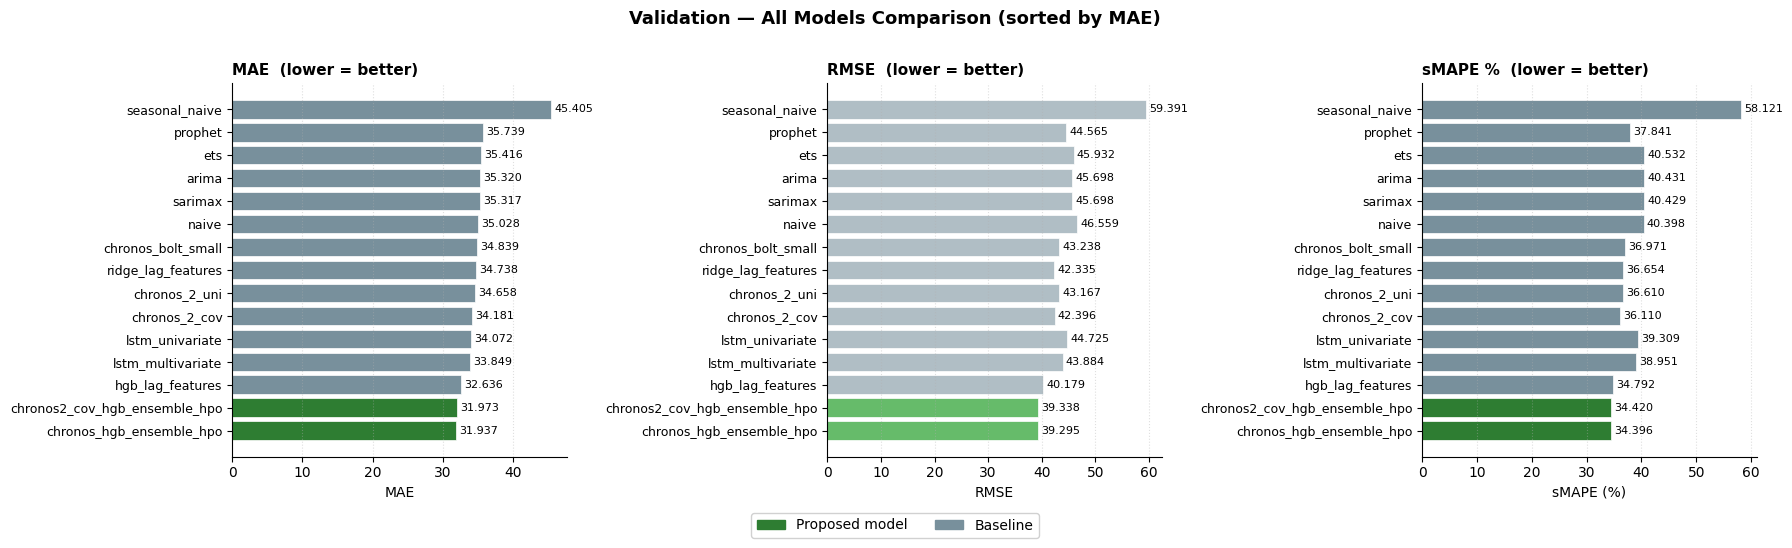

In [30]:
# ── Visual comparison: all models in val_table, sorted by val_MAE ─────────────

import matplotlib.patches as mpatches



_PROPOSED = {

    "chronos2_cov_hgb_ensemble_hpo",

    "chronos_hgb_ensemble_hpo",

}



_vt = val_table.copy().sort_values("val_MAE", ascending=True).reset_index(drop=True)



labels  = _vt["model"].tolist()

mae_v   = _vt["val_MAE"].tolist()

rmse_v  = _vt["val_RMSE"].tolist()

smape_v = _vt["val_sMAPE"].tolist()



colors_mae  = ["#2e7d32" if m in _PROPOSED else "#78909c" for m in labels]

colors_rmse = ["#66bb6a" if m in _PROPOSED else "#b0bec5" for m in labels]



fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fig.suptitle("Validation — All Models Comparison (sorted by MAE)", fontsize=13,

             fontweight="bold", y=1.01)



y_pos = np.arange(len(labels))



for ax, vals, cols, title, xlabel in [

    (axes[0], mae_v,   colors_mae,  "MAE  (lower = better)",   "MAE"),

    (axes[1], rmse_v,  colors_rmse, "RMSE  (lower = better)",  "RMSE"),

    (axes[2], smape_v, colors_mae,  "sMAPE %  (lower = better)","sMAPE (%)"),

]:

    bars = ax.barh(y_pos, vals, color=cols, edgecolor="white", linewidth=0.5)

    for bar, v in zip(bars, vals):

        if not np.isnan(v):

            ax.text(v + max(vals) * 0.01, bar.get_y() + bar.get_height() / 2,

                    f"{v:.3f}", va="center", fontsize=8)

    ax.set_yticks(y_pos)

    ax.set_yticklabels(labels, fontsize=9)

    ax.set_xlabel(xlabel, fontsize=10)

    ax.set_title(title, fontsize=11, fontweight="bold", loc="left")

    ax.spines["top"].set_visible(False)

    ax.spines["right"].set_visible(False)

    ax.grid(axis="x", linestyle=":", alpha=0.4)

    ax.set_xlim(left=0)



legend_patches = [

    mpatches.Patch(color="#2e7d32", label="Proposed model"),

    mpatches.Patch(color="#78909c", label="Baseline"),

]

fig.legend(handles=legend_patches, loc="lower center", ncol=2,

           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))



plt.tight_layout()

plt.show()

## Phase 7 — Feature importance — proposed (HGB ensemble HPO)

Phân tích feature importance của thành phần **HGB** trong proposed ensemble:
- Lag feature nào được model học nhiều nhất
- Rolling statistics vs. calendar features: cái nào quan trọng hơn
- **Feature importance:** gain của HGB (khớp với model đang fit cho blend)


Computing permutation importance on val set (n_repeats=10) ...
Feature Importance — HGB component of Chronos-2+HGB (HPO)
  HPO (Optuna) |  alpha* (Chronos weight): 0.318


,feature,importance,std
0,Inventory Level,0.243804,0.008079
1,Promotion,0.112189,0.004383
2,Epidemic,0.091654,0.003631
3,Price,0.026635,0.001580
4,dayofyear,0.006979,0.000760
5,Competitor Pricing,0.006501,0.000806
6,roll_mean_28,0.003428,0.000635
7,lag_3,0.001717,0.000491
8,roll_mean_14,0.001450,0.000465
9,roll_mean_7,0.001121,0.000508


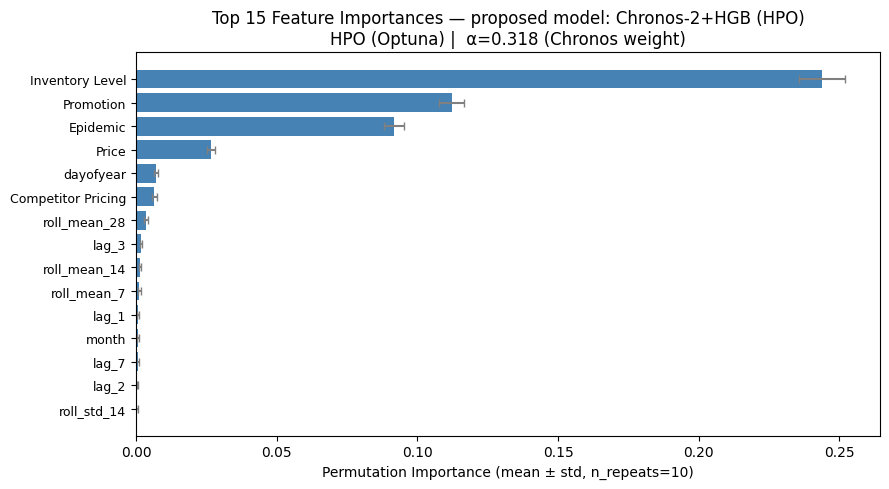

In [31]:
# === Feature Importance: HGB component of Chronos-2+HGB (HPO) ===
# Note: HistGradientBoostingRegressor does NOT expose .feature_importances_
# → use permutation importance on val set instead (model-agnostic, reliable)

from sklearn.inspection import permutation_importance as _perm_imp

if HPO_ENSEMBLE_AVAILABLE and _best_hgb_params and "hpo" in _best_hgb_params:
    _best_key = "hpo"
    _best_params, _best_hgb, _best_alpha = _best_hgb_params[_best_key]

    print(f"Computing permutation importance on val set (n_repeats=10) ...")
    _perm = _perm_imp(_best_hgb, X_val, y_val, n_repeats=10,
                      random_state=RANDOM_SEED, n_jobs=-1)
    imp_df_hpo = pd.DataFrame({
        'feature':    feature_cols,
        'importance': _perm.importances_mean,
        'std':        _perm.importances_std,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print(f"Feature Importance — HGB component of Chronos-2+HGB (HPO)")
    print(f"  HPO (Optuna) |  alpha* (Chronos weight): {_best_alpha:.3f}")
    display(imp_df_hpo.head(15))

    _top_fi = imp_df_hpo.head(15).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(_top_fi['feature'], _top_fi['importance'],
            xerr=_top_fi['std'], color='steelblue', ecolor='gray', capsize=3)
    ax.set_xlabel('Permutation Importance (mean ± std, n_repeats=10)')
    ax.set_title(
        f'Top 15 Feature Importances — proposed model: Chronos-2+HGB (HPO)\n'
        f'HPO (Optuna) |  α={_best_alpha:.3f} (Chronos weight)'
    )
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.show()

else:
    imp_df_hpo = pd.DataFrame(columns=['feature', 'importance'])
    print("HPO ensemble not available — feature importance skipped.")


## Phase 9 — Error analysis — proposed model (Chronos-2+HGB + HPO)

Phân tích lỗi **proposed model** theo 5 chiều, so sánh với Naive và Seasonal Naive:

| Panel | Chiều phân tích | Câu hỏi |
|---|---|---|
| 1 | **Theo thời gian** | Lỗi có tăng dần về cuối val? Có drift? |
| 2 | **Day-of-week** | Sai nhiều hơn vào cuối tuần không? |
| 3 | **Peak vs Trough** | Sai nhiều hơn ở demand cao hay thấp? |
| 4 | **Promotion vs Normal** | Promotion spike có được nắm bắt không? |
| 5 | **Per-series distribution** | Series nào có MAE cao nhất? |


Top-3 worst series (highest val MAE):
  Store=S002  Product=P0004  MAE=41.5296
  Store=S003  Product=P0015  MAE=40.0127
  Store=S005  Product=P0009  MAE=39.6442


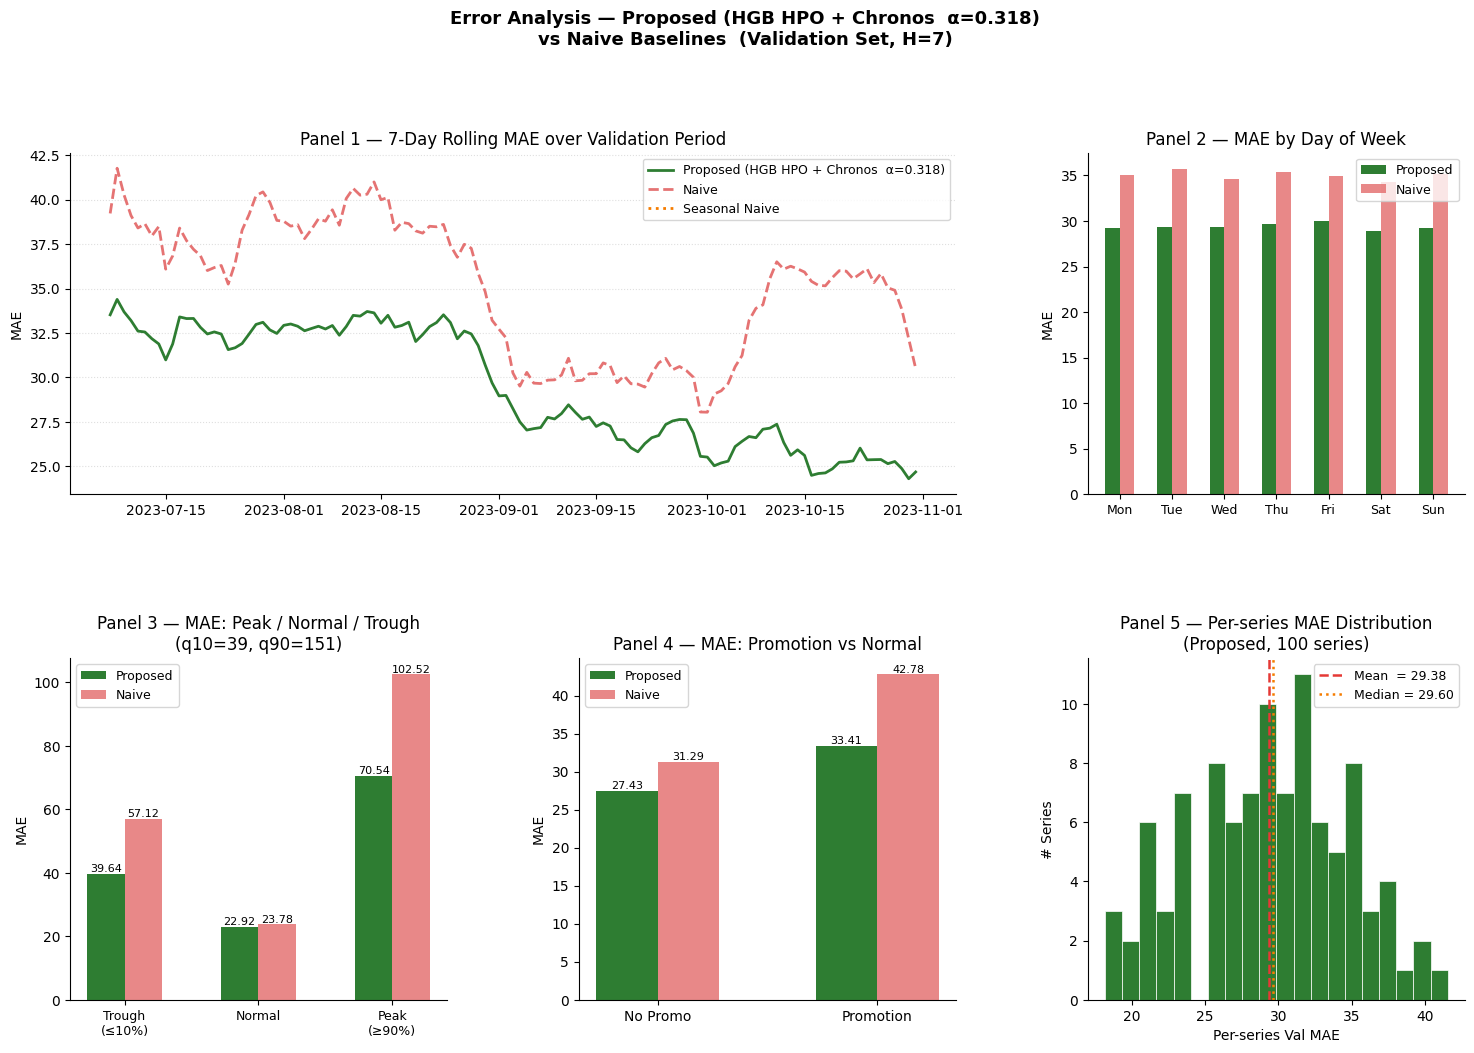


=== Error Analysis Summary — Proposed (HGB HPO + Chronos  α=0.318) ===
Overall val MAE:           29.3771
Naive val MAE:             35.0277
Peak demand MAE   (≥90%):  70.5440
Normal demand MAE:         22.9191
Trough demand MAE (≤10%):  39.6386
Promotion=1 MAE:           33.4112
Promotion=0 MAE:           27.4330


In [32]:
# === Error Analysis — Proposed Model (Chronos-2+HGB + HPO) ===
from matplotlib.gridspec import GridSpec

# ── HPO HGB component for per-timestep analysis ─────────────────────────────
if HPO_ENSEMBLE_AVAILABLE and _best_hgb_params and "hpo" in _best_hgb_params:
    _, _ea_hgb, _ea_alpha = _best_hgb_params["hpo"]
    val_pred_proposed = np.clip(_ea_hgb.predict(X_val), 0, None)
    _model_label = f"Proposed (HGB HPO + Chronos  α={_ea_alpha:.3f})"
else:
    val_pred_proposed = val_pred_hgb
    _model_label = "HGB (fallback — HPO not available)"

# ── Build error dataframe (aligned to val_feat / X_val) ──────────────────────
# Compute abserr_snaive BEFORE reset_index so val_df label alignment is preserved
_vf = val_feat.copy()
_vf["Date"]            = pd.to_datetime(_vf["Date"])
_vf["y_true"]          = y_val.values
_vf["abserr_proposed"] = np.abs(val_pred_proposed - _vf["y_true"])
_vf["abserr_naive"]    = np.abs(last_train_value  - _vf["y_true"])

# val_pred_snaive is positionally aligned to val_df; reindex via original index labels
_snaive_s = pd.Series(val_pred_snaive, index=val_df.index)
_vf["abserr_snaive"] = np.abs(_snaive_s.reindex(_vf.index).values - _vf["y_true"].values)

_vf = _vf.reset_index(drop=True)

# ── Demand segments ───────────────────────────────────────────────────────────
q10, q90 = _vf["y_true"].quantile(0.10), _vf["y_true"].quantile(0.90)
_vf["segment"] = "Normal"
_vf.loc[_vf["y_true"] >= q90, "segment"] = "Peak\n(≥90%)"
_vf.loc[_vf["y_true"] <= q10, "segment"] = "Trough\n(≤10%)"
_seg_order = ["Trough\n(≤10%)", "Normal", "Peak\n(≥90%)"]

# ── Figure layout: 2 rows × 3 cols ───────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.suptitle(f"Error Analysis — {_model_label}\nvs Naive Baselines  (Validation Set, H=7)",
             fontsize=13, fontweight="bold", y=1.01)
gs = GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :2])   # wide: error over time
ax2 = fig.add_subplot(gs[0, 2])    # day-of-week
ax3 = fig.add_subplot(gs[1, 0])    # peak vs trough
ax4 = fig.add_subplot(gs[1, 1])    # promotion
ax5 = fig.add_subplot(gs[1, 2])    # per-series distribution

_C_PROP  = "#2e7d32"
_C_NAIVE = "#e57373"
_C_SN    = "#f57c00"
_W = 0.28

# ── Panel 1: Rolling error over time ─────────────────────────────────────────
_daily = _vf.groupby("Date")[["abserr_proposed", "abserr_naive", "abserr_snaive"]].mean()
for col, label, color, ls in [
    ("abserr_proposed", _model_label,    _C_PROP,  "-"),
    ("abserr_naive",    "Naive",         _C_NAIVE, "--"),
    ("abserr_snaive",   "Seasonal Naive",_C_SN,    ":"),
]:
    ax1.plot(_daily.index, _daily[col].rolling(7).mean(),
             label=label, color=color, linestyle=ls, linewidth=2)
ax1.set_title("Panel 1 — 7-Day Rolling MAE over Validation Period")
ax1.set_ylabel("MAE")
ax1.legend(fontsize=9)
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", linestyle=":", alpha=0.4)

# ── Panel 2: MAE by Day of Week ──────────────────────────────────────────────
_dow = _vf.groupby("dayofweek")[["abserr_proposed", "abserr_naive"]].mean()
_dow.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
x = np.arange(len(_dow))
ax2.bar(x - _W/2, _dow["abserr_proposed"], _W, label="Proposed", color=_C_PROP)
ax2.bar(x + _W/2, _dow["abserr_naive"],    _W, label="Naive",    color=_C_NAIVE, alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(_dow.index, fontsize=9)
ax2.set_title("Panel 2 — MAE by Day of Week")
ax2.set_ylabel("MAE")
ax2.legend(fontsize=9)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

# ── Panel 3: Peak vs Trough ──────────────────────────────────────────────────
_seg = _vf.groupby("segment")[["abserr_proposed", "abserr_naive"]].mean().reindex(_seg_order)
x3 = np.arange(len(_seg_order))
ax3.bar(x3 - _W/2, _seg["abserr_proposed"], _W, label="Proposed", color=_C_PROP)
ax3.bar(x3 + _W/2, _seg["abserr_naive"],    _W, label="Naive",    color=_C_NAIVE, alpha=0.85)
ax3.set_xticks(x3); ax3.set_xticklabels(_seg_order, fontsize=9)
ax3.set_title(f"Panel 3 — MAE: Peak / Normal / Trough\n(q10={q10:.0f}, q90={q90:.0f})")
ax3.set_ylabel("MAE")
ax3.legend(fontsize=9)
for p in ax3.patches:
    ax3.annotate(f"{p.get_height():.2f}",
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha="center", va="bottom", fontsize=8)
ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)

# ── Panel 4: Promotion vs Non-promotion ──────────────────────────────────────
if "Promotion" in _vf.columns:
    _promo = _vf.groupby("Promotion")[["abserr_proposed", "abserr_naive"]].mean()
    _promo.index = ["No Promo", "Promotion"]
    x4 = np.arange(2)
    ax4.bar(x4 - _W/2, _promo["abserr_proposed"], _W, label="Proposed", color=_C_PROP)
    ax4.bar(x4 + _W/2, _promo["abserr_naive"],    _W, label="Naive",    color=_C_NAIVE, alpha=0.85)
    ax4.set_xticks(x4); ax4.set_xticklabels(_promo.index, fontsize=10)
    for p in ax4.patches:
        ax4.annotate(f"{p.get_height():.2f}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=8)
    ax4.legend(fontsize=9)
else:
    ax4.text(0.5, 0.5, "Promotion column\nnot in features",
             ha="center", va="center", transform=ax4.transAxes, fontsize=10, color="#9e9e9e")
ax4.set_title("Panel 4 — MAE: Promotion vs Normal")
ax4.set_ylabel("MAE")
ax4.spines["top"].set_visible(False); ax4.spines["right"].set_visible(False)

# ── Panel 5: Per-series MAE distribution ─────────────────────────────────────
if "Store ID" in _vf.columns and "Product ID" in _vf.columns:
    _series_mae = _vf.groupby(["Store ID", "Product ID"])["abserr_proposed"].mean()
    ax5.hist(_series_mae, bins=20, color=_C_PROP, edgecolor="white", linewidth=0.5)
    ax5.axvline(_series_mae.mean(),   color="#e53935", linestyle="--", linewidth=1.8,
                label=f"Mean  = {_series_mae.mean():.2f}")
    ax5.axvline(_series_mae.median(), color=_C_SN,    linestyle=":",  linewidth=1.8,
                label=f"Median = {_series_mae.median():.2f}")
    ax5.set_xlabel("Per-series Val MAE")
    ax5.set_ylabel("# Series")
    ax5.legend(fontsize=9)
    # Annotate worst series
    _worst = _series_mae.nlargest(3)
    print(f"Top-3 worst series (highest val MAE):")
    for (st, pr), v in _worst.items():
        print(f"  Store={st}  Product={pr}  MAE={v:.4f}")
else:
    ax5.text(0.5, 0.5, "Series info not available", ha="center", va="center",
             transform=ax5.transAxes, fontsize=10, color="#9e9e9e")
ax5.set_title("Panel 5 — Per-series MAE Distribution\n(Proposed, 100 series)")
ax5.spines["top"].set_visible(False); ax5.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n=== Error Analysis Summary — {_model_label} ===")
print(f"Overall val MAE:           {_vf['abserr_proposed'].mean():.4f}")
print(f"Naive val MAE:             {_vf['abserr_naive'].mean():.4f}")
_peak_mae   = _vf[_vf["segment"] == "Peak\n(≥90%)"]["abserr_proposed"].mean()
_trough_mae = _vf[_vf["segment"] == "Trough\n(≤10%)"]["abserr_proposed"].mean()
_normal_mae = _vf[_vf["segment"] == "Normal"]["abserr_proposed"].mean()
print(f"Peak demand MAE   (≥90%):  {_peak_mae:.4f}")
print(f"Normal demand MAE:         {_normal_mae:.4f}")
print(f"Trough demand MAE (≤10%):  {_trough_mae:.4f}")
if "Promotion" in _vf.columns:
    print(f"Promotion=1 MAE:           {_vf[_vf['Promotion']==1]['abserr_proposed'].mean():.4f}")
    print(f"Promotion=0 MAE:           {_vf[_vf['Promotion']==0]['abserr_proposed'].mean():.4f}")

  val (Bolt raw dict): 100 series accepted, 0 skipped
⚠️  Could not reconstruct Chronos-Bolt from raw dict: NumPy boolean array indexing assignment cannot assign 7 input values to the 123 output values where the mask is true
ℹ️  Chronos-Bolt flat predictions unavailable — showing HGB vs Proposed only.


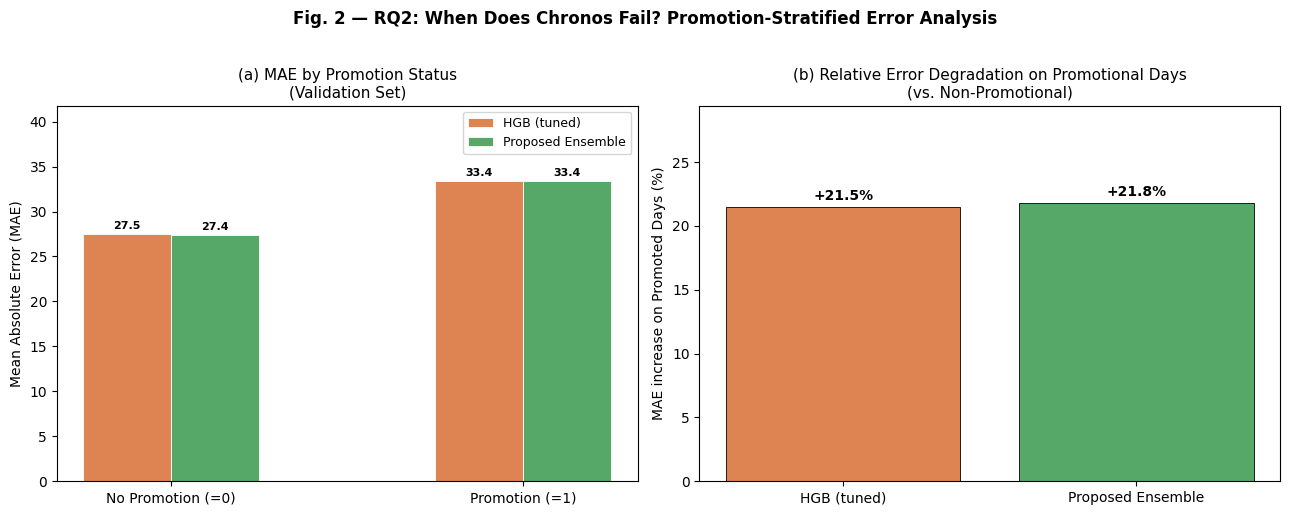

✅ Saved → outputs/fig2_promotion_error_analysis.png

── Promotion-stratified MAE ──
           HGB (tuned)  Proposed Ensemble
Promotion                                
0                27.49              27.43
1                33.39              33.41

── Relative degradation on promoted days ──
  HGB (tuned): +21.5%
  Proposed Ensemble: +21.8%


In [33]:

# === Fig. 2 — Promotion-Stratified MAE: Chronos-Bolt vs HGB vs Proposed (RQ2) ===
# Requires: _vf (Phase 9), val_pred_hgb, val_df, _chronos_bolt_raw_dict or chronos_val_records

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    # ── 1. Build base dataframe from _vf (Phase 9) ────────────────────────────
    assert "_vf" in dir() or "_vf" in globals(), "_vf not found; run Phase 9 first"
    _f2 = _vf[["y_true", "Promotion", "Date"]].copy() if "Date" in _vf.columns else _vf[["y_true", "Promotion"]].copy()

    # ── 2. HGB absolute errors ─────────────────────────────────────────────────
    assert "val_pred_hgb" in globals(), "val_pred_hgb not found"
    _f2["abserr_hgb"] = np.abs(np.asarray(val_pred_hgb) - _f2["y_true"].values)

    # ── 3. Proposed ensemble errors (already in _vf) ───────────────────────────
    # abserr_proposed is set by Phase 9

    # ── 4. Chronos-Bolt: reconstruct flat predictions from raw dict ────────────
    _chronos_bolt_preds_flat = None
    if globals().get("_chronos_bolt_raw_dict") is not None:
        try:
            _bolt_val_raw = _chronos_bolt_raw_dict(TRAIN_END, "val")   # {(store,product): array(H)}
            # _vf has multi-index or reset; align via val_df index
            _val_df_reset = val_df.reset_index(drop=True).copy()
            _bolt_flat = np.full(len(_val_df_reset), np.nan)
            for (sid, pid), preds in _bolt_val_raw.items():
                mask = (_val_df_reset["Store ID"] == sid) & (_val_df_reset["Product ID"] == pid)
                _bolt_flat[mask] = preds[:mask.sum()]
            if not np.isnan(_bolt_flat).all():
                _chronos_bolt_preds_flat = _bolt_flat
                print("✅ Chronos-Bolt predictions reconstructed from raw dict.")
        except Exception as _eb:
            print(f"⚠️  Could not reconstruct Chronos-Bolt from raw dict: {_eb}")

    if _chronos_bolt_preds_flat is None:
        print("ℹ️  Chronos-Bolt flat predictions unavailable — showing HGB vs Proposed only.")

    # ── 5. Compute promotion-stratified MAE ───────────────────────────────────
    _f2["abserr_proposed"] = _vf["abserr_proposed"].values
    if _chronos_bolt_preds_flat is not None:
        _f2["abserr_chronos"] = np.abs(_chronos_bolt_preds_flat - _f2["y_true"].values)

    _promo = _f2.groupby("Promotion")

    _model_cols   = ["abserr_hgb", "abserr_proposed"]
    _model_labels = ["HGB (tuned)", "Proposed Ensemble"]
    _colors       = ["#dd8452", "#55a868"]
    if "abserr_chronos" in _f2.columns:
        _model_cols   = ["abserr_chronos"] + _model_cols
        _model_labels = ["Chronos-Bolt"] + _model_labels
        _colors       = ["#4c72b0"] + _colors

    _promo_mae = _promo[_model_cols].mean()

    # ── 6. Plot ────────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    x  = np.arange(2)
    w  = 0.25
    xlabels = ["No Promotion (=0)", "Promotion (=1)"]

    for j, (col, label, c) in enumerate(zip(_model_cols, _model_labels, _colors)):
        vals = [_promo_mae.loc[0, col], _promo_mae.loc[1, col]]
        offset = (j - (len(_model_cols) - 1) / 2) * w
        bars = ax1.bar(x + offset, vals, w, label=label, color=c, edgecolor="white", linewidth=0.6)
        for bar, v in zip(bars, vals):
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f"{v:.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax1.set_xticks(x)
    ax1.set_xticklabels(xlabels, fontsize=10)
    ax1.set_ylabel("Mean Absolute Error (MAE)", fontsize=10)
    ax1.set_title("(a) MAE by Promotion Status\n(Validation Set)", fontsize=11)
    ax1.legend(fontsize=9)
    ax1.set_ylim(0, _promo_mae.max().max() * 1.25)

    # Panel 2: relative degradation (%)
    _degradation = [
        (_promo_mae.loc[1, c] - _promo_mae.loc[0, c]) / _promo_mae.loc[0, c] * 100
        for c in _model_cols
    ]
    bars2 = ax2.bar(_model_labels, _degradation, color=_colors, edgecolor="black", linewidth=0.6)
    for bar, v in zip(bars2, _degradation):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"+{v:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax2.set_ylabel("MAE increase on Promoted Days (%)", fontsize=10)
    ax2.set_title("(b) Relative Error Degradation on Promotional Days\n(vs. Non-Promotional)", fontsize=11)
    ax2.set_ylim(0, max(_degradation) * 1.35)

    plt.suptitle("Fig. 2 — RQ2: When Does Chronos Fail? Promotion-Stratified Error Analysis",
                 fontsize=12, y=1.02, fontweight="bold")
    plt.tight_layout()

    _out = os.path.join(OUTPUT_DIR, "fig2_promotion_error_analysis.png")
    plt.savefig(_out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {_out}")

    print("\n── Promotion-stratified MAE ──")
    print(_promo_mae[_model_cols].rename(columns=dict(zip(_model_cols, _model_labels))).round(2))
    print("\n── Relative degradation on promoted days ──")
    for lbl, d in zip(_model_labels, _degradation):
        print(f"  {lbl}: +{d:.1f}%")

except Exception as _e:
    print(f"⚠️  Fig. 2 skipped: {type(_e).__name__}: {_e}")


## Phase 10 — Ablation study — proposed model (Chronos-2+HGB + HPO)

Kiểm tra đóng góp của từng thành phần trong proposed model bằng cách **loại bỏ hoặc thay thế từng phần**.  
Tất cả đánh giá trên **validation set** (train_end → val_end), dùng (H=7, no oracle lags).

| Ablation | Thay đổi | Câu hỏi trả lời |
|---|---|---|
| **B1** Chronos Only | α = 1.0 (HGB weight = 0) | HGB có thực sự cần thiết? |
| **B2** HGB Only | α = 0.0 (Chronos weight = 0) | Chronos có thực sự cần thiết? |
| **B3** No HPO | Default HGB params, α* từ sweep | Tối ưu hyperparams mang lại bao nhiêu? |
| **B4** No Lag Features | Bỏ lag_1/2/3/7/14/28 | Memory ngắn hạn đóng góp bao nhiêu? |
| **B5** No Calendar Features | Bỏ dayofweek/month/dayofyear | Seasonality encoding có cần? |
| **B6** No Exogenous Features | Bỏ Price/Discount/Promotion/Epidemic/... | Business signals có giúp HGB? |


Feature groups:
  Lag (6): ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_28']
  Rolling (6): ['roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_28', 'roll_std_28']
  Calendar (3): ['dayofweek', 'month', 'dayofyear']
  Exogenous (6): ['Inventory Level', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Epidemic']
  [val] Chronos-2 proposed: target=['Units Sold'], past_cov=17, future_cov=['dayofweek', 'month', 'dayofyear', 'Price', 'Discount'], 100 series, 0 skipped

✅ Chronos-2 val preds: 100 series
  val (Bolt raw dict): 100 series accepted, 0 skipped
✅ Chronos-Bolt val preds: 100 series

Ablation suite: Chronos-2 (cov) + HGB (HPO)
  FULL  MAE=31.9728  RMSE=39.3382  sMAPE=34.4197
  B1    MAE=34.1808  RMSE=42.3959  sMAPE=36.1095
  B2    MAE=32.4347  RMSE=39.9221  sMAPE=34.525
  B3    MAE=32.3634  RMSE=39.8305  sMAPE=34.7279
  B4    MAE=32.0821  RMSE=39.4386  sMAPE=34.4973
  B5    MAE=31.9497  RMSE=39.3821  sMAPE=34.39
  B6    MAE=34.9184  RMSE=43.5256  

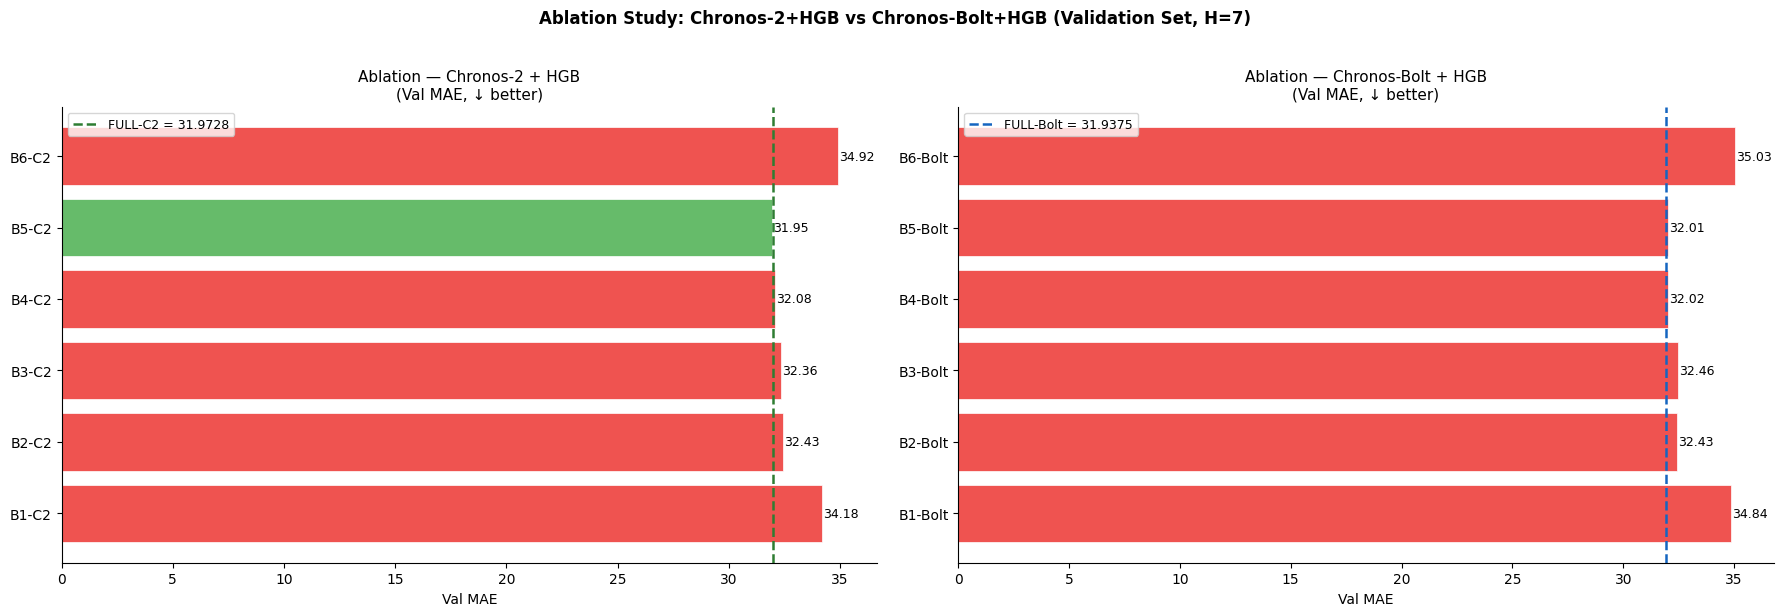

✅ Saved → outputs/ablation_proposed_model.png
✅ Saved ablation CSV → outputs/ablation_proposed_b1b6_summary.csv  (14 rows)


In [34]:
# === Ablation Study — Both Proposed Variants: Chronos-2+HGB and Bolt+HGB ===
# Runs full B1–B6 ablation independently for each variant.
# Requires: CHRONOS2_AVAILABLE, `_chronos_raw`, _chronos_bolt_raw_dict, _best_hgb_params
# All evaluations on validation set via (H=7, no oracle lags)

from sklearn.ensemble import HistGradientBoostingRegressor as _HGB

# ── Feature groups ────────────────────────────────────────────────────────────
_LAG_COLS      = [c for c in feature_cols if c.startswith("lag_")]
_ROLL_COLS     = [c for c in feature_cols if c.startswith("roll_")]
_CALENDAR_COLS = [c for c in feature_cols if c in ("dayofweek", "month", "dayofyear")]
_EXOG_COLS     = [c for c in feature_cols if c not in _LAG_COLS + _ROLL_COLS + _CALENDAR_COLS]

print("Feature groups:")
print(f"  Lag ({len(_LAG_COLS)}): {_LAG_COLS}")
print(f"  Rolling ({len(_ROLL_COLS)}): {_ROLL_COLS}")
print(f"  Calendar ({len(_CALENDAR_COLS)}): {_CALENDAR_COLS}")
print(f"  Exogenous ({len(_EXOG_COLS)}): {_EXOG_COLS}")

# ── Guard ─────────────────────────────────────────────────────────────────────
if not (CHRONOS2_AVAILABLE and globals().get("_chronos_raw") is not None):
    print("⚠️  Chronos-2 not available — ablation skipped.")
    _ablation_records = []
else:
    # ── Load Chronos val predictions ─────────────────────────────────────────
    _c2_val_abl = _chronos_raw(context_end=TRAIN_END, prefix='val')
    print(f"\n✅ Chronos-2 val preds: {len(_c2_val_abl)} series")

    _bolt_val_abl = None
    if globals().get("_chronos_bolt_raw_dict") is not None:
        try:
            _bolt_val_abl = _chronos_bolt_raw_dict(TRAIN_END, "val")
            print(f"✅ Chronos-Bolt val preds: {len(_bolt_val_abl)} series")
        except Exception as _eb:
            print(f"⚠️  Chronos-Bolt val preds unavailable: {_eb}")

    # ── Best HPO params (shared HGB component) ────────────────────────────────
    _best_key = (
        _hpo_best_strategy_key
        if (_hpo_best_strategy_key and _hpo_best_strategy_key in _best_hgb_params)
        else ("hpo" if _best_hgb_params and "hpo" in _best_hgb_params else None)
    )
    _best_bp, _, _best_alpha = _best_hgb_params[_best_key] if _best_key else ({}, None, 0.5)
    _best_hgb_p = {k: v for k, v in _best_bp.items() if k != "alpha"}
    _best_hgb_p["random_state"] = RANDOM_SEED
    _default_hgb_p = {"max_depth": 5, "learning_rate": 0.05, "random_state": RANDOM_SEED}

    def _abl_eval(ablation_id, label, feat_subset, alpha_val, chronos_preds, hgb_params=None):
        """Fit HGB on feat_subset, blend with chronos_preds at alpha_val, eval on val."""
        _p = hgb_params or _default_hgb_p
        _m = _HGB(**_p)
        _m.fit(train_feat[feat_subset], train_feat["Units Sold"])
        _h_val = build_hgb_horizon_predictions(_m, TRAIN_END, df, feat_subset)
        _met, _ = _blend_eval(chronos_preds, _h_val, alpha_val, 'val')
        return {
            "ablation": ablation_id, "label": label,
            "alpha": round(alpha_val, 3), "n_features": len(feat_subset),
            "val_MAE":   round(_met["val_MAE"],   4),
            "val_RMSE":  round(_met["val_RMSE"],  4),
            "val_sMAPE": round(_met["val_sMAPE"], 4),
        }

    def _run_ablations(tag, chronos_preds, full_metrics, full_label):
        """Run full B1–B6 suite for one Chronos variant."""
        print(f"\n{'='*60}")
        print(f"Ablation suite: {full_label}")
        print(f"{'='*60}")

        # FULL reference
        _full = {
            "ablation": f"FULL-{tag}", "label": full_label,
            "alpha": round(_best_alpha, 3), "n_features": len(feature_cols),
            "val_MAE":   round(full_metrics.get("val_MAE",   float("nan")), 4),
            "val_RMSE":  round(full_metrics.get("val_RMSE",  float("nan")), 4),
            "val_sMAPE": round(full_metrics.get("val_sMAPE", float("nan")), 4),
        }
        print(f"  FULL  MAE={_full['val_MAE']}  RMSE={_full['val_RMSE']}  sMAPE={_full['val_sMAPE']}")

        # B1: Chronos Only
        _h_zeros = {k: np.zeros(HORIZON_DAYS) for k in chronos_preds}
        _b1m, _ = _blend_eval(chronos_preds, _h_zeros, 1.0, 'val')
        _b1 = {"ablation": f"B1-{tag}", "label": f"{tag} Only (α=1)", "alpha": 1.0, "n_features": 0,
               "val_MAE": round(_b1m["val_MAE"], 4), "val_RMSE": round(_b1m["val_RMSE"], 4),
               "val_sMAPE": round(_b1m["val_sMAPE"], 4)}
        print(f"  B1    MAE={_b1['val_MAE']}  RMSE={_b1['val_RMSE']}  sMAPE={_b1['val_sMAPE']}")

        # B2: HGB Only
        _b2 = _abl_eval(f"B2-{tag}", "HGB Only (α=0)", feature_cols, 0.0, chronos_preds, _best_hgb_p)
        print(f"  B2    MAE={_b2['val_MAE']}  RMSE={_b2['val_RMSE']}  sMAPE={_b2['val_sMAPE']}")

        # B3: No HPO
        _b3 = _abl_eval(f"B3-{tag}", "No HPO (default, α=0.5)", feature_cols, 0.5, chronos_preds, _default_hgb_p)
        print(f"  B3    MAE={_b3['val_MAE']}  RMSE={_b3['val_RMSE']}  sMAPE={_b3['val_sMAPE']}")

        # B4: No Lag
        _feat_no_lag = [c for c in feature_cols if c not in _LAG_COLS]
        _b4 = _abl_eval(f"B4-{tag}", f"No Lag (–{len(_LAG_COLS)})", _feat_no_lag, _best_alpha, chronos_preds, _best_hgb_p)
        print(f"  B4    MAE={_b4['val_MAE']}  RMSE={_b4['val_RMSE']}  sMAPE={_b4['val_sMAPE']}")

        # B5: No Calendar
        _feat_no_cal = [c for c in feature_cols if c not in _CALENDAR_COLS]
        _b5 = _abl_eval(f"B5-{tag}", f"No Calendar (–{len(_CALENDAR_COLS)})", _feat_no_cal, _best_alpha, chronos_preds, _best_hgb_p)
        print(f"  B5    MAE={_b5['val_MAE']}  RMSE={_b5['val_RMSE']}  sMAPE={_b5['val_sMAPE']}")

        # B6: No Exogenous
        _feat_no_exog = [c for c in feature_cols if c not in _EXOG_COLS]
        _b6 = _abl_eval(f"B6-{tag}", f"No Exogenous (–{len(_EXOG_COLS)})", _feat_no_exog, _best_alpha, chronos_preds, _best_hgb_p)
        print(f"  B6    MAE={_b6['val_MAE']}  RMSE={_b6['val_RMSE']}  sMAPE={_b6['val_sMAPE']}")

        rows = [_full, _b1, _b2, _b3, _b4, _b5, _b6]
        _df = pd.DataFrame(rows)
        _df["ΔMAE"]  = (_df["val_MAE"]  - _full["val_MAE"]).round(4)
        _df["Δ%MAE"] = ((_df["val_MAE"] / _full["val_MAE"] - 1) * 100).round(2)
        _df.loc[_df["ablation"] == f"FULL-{tag}", ["ΔMAE", "Δ%MAE"]] = 0.0
        return _df

    # ── Run for Chronos-2 + HGB ───────────────────────────────────────────────
    abl_c2_df = _run_ablations(
        "C2", _c2_val_abl,
        ensemble_hpo_val_metrics,
        "Chronos-2 (cov) + HGB (HPO)"
    )

    # ── Run for Chronos-Bolt + HGB ────────────────────────────────────────────
    abl_bolt_df = None
    if _bolt_val_abl is not None:
        abl_bolt_df = _run_ablations(
            "Bolt", _bolt_val_abl,
            chronos_hgb_ensemble_hpo_val_metrics,
            "Chronos-Bolt + HGB (HPO)"
        )
    else:
        print("\n⚠️  Skipping Bolt ablation — val preds unavailable.")

    # ── Print summary tables ──────────────────────────────────────────────────
    print("\n" + "="*70)
    print("ABLATION SUMMARY — Chronos-2 (cov) + HGB (val set, H=7)")
    print("="*70)
    print(abl_c2_df[["ablation","label","alpha","n_features","val_MAE","val_RMSE","val_sMAPE","ΔMAE","Δ%MAE"]].to_string(index=False))

    if abl_bolt_df is not None:
        print("\n" + "="*70)
        print("ABLATION SUMMARY — Chronos-Bolt + HGB (val set, H=7)")
        print("="*70)
        print(abl_bolt_df[["ablation","label","alpha","n_features","val_MAE","val_RMSE","val_sMAPE","ΔMAE","Δ%MAE"]].to_string(index=False))

    # ── Visualization: side-by-side bar charts ────────────────────────────────
    _variants = [("C2", abl_c2_df, "#2e7d32", "Chronos-2 + HGB")]
    if abl_bolt_df is not None:
        _variants.append(("Bolt", abl_bolt_df, "#1565c0", "Chronos-Bolt + HGB"))

    _ncols = len(_variants)
    fig, axes = plt.subplots(1, _ncols, figsize=(9 * _ncols, 6), sharey=False)
    if _ncols == 1:
        axes = [axes]

    for ax, (tag, _df, color, title) in zip(axes, _variants):
        _full_row = _df[_df["ablation"] == f"FULL-{tag}"].iloc[0]
        _abl_rows = _df[_df["ablation"] != f"FULL-{tag}"]
        _vals   = _abl_rows["val_MAE"].values
        _labels = _abl_rows["ablation"].values
        _colors = ["#ef5350" if v > _full_row["val_MAE"] else "#66bb6a" for v in _vals]
        bars = ax.barh(_labels, _vals, color=_colors, edgecolor="white", linewidth=0.5)
        ax.axvline(_full_row["val_MAE"], color=color, linestyle="--", linewidth=1.8,
                   label=f"FULL-{tag} = {_full_row['val_MAE']:.4f}")
        for bar, v in zip(bars, _vals):
            ax.text(v + 0.05, bar.get_y() + bar.get_height()/2,
                    f"{v:.2f}", va="center", ha="left", fontsize=9)
        ax.set_title(f"Ablation — {title}\n(Val MAE, ↓ better)", fontsize=11)
        ax.set_xlabel("Val MAE")
        ax.legend(fontsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle("Ablation Study: Chronos-2+HGB vs Chronos-Bolt+HGB (Validation Set, H=7)",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ablation_proposed_model.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved → outputs/ablation_proposed_model.png")

    # ── Export ────────────────────────────────────────────────────────────────
    _all_abl = pd.concat([abl_c2_df] + ([abl_bolt_df] if abl_bolt_df is not None else []), ignore_index=True)
    _all_abl["horizon"] = HORIZON_DAYS
    _csv_path = os.path.join(OUTPUT_DIR, "ablation_proposed_b1b6_summary.csv")
    _all_abl.to_csv(_csv_path, index=False)
    _ablation_records = _all_abl.to_dict("records")
    print(f"✅ Saved ablation CSV → {_csv_path}  ({len(_all_abl)} rows)")

## Phase 11 — Final test evaluation

Cần chọn best model trên validation rồi mới đánh giá test.  
Không dùng kết quả đánh giá test để lựa chọn best model.


Sau ô code test: **`test_table`** (tất cả model) và **`test_table_by_group`** (gom classical / ML / pretrained / proposed).


In [35]:
best_model_name = val_table.iloc[0]["model"]
print("Best validation model:", best_model_name)


Best validation model: chronos_hgb_ensemble_hpo


Có thể retrain với toàn bộ dữ liệu train + validation để có model cuối cùng trước khi test.

In [36]:
# Prepare test predictions consistently
last_train_val = df[df["Date"] < "2023-11-01"]["Units Sold"].iloc[-1]
test_pred_naive = np.repeat(last_train_val, len(test_df))
history_until_test = df[df["Date"] < "2023-11-01"]["Units Sold"].values
test_pred_snaive = seasonal_naive_predict(history_until_test, len(test_df), season_length=7)
# Refit ARIMA on train + val
trainval_df = df[df["Date"] < "2023-11-01"].copy()
arima_tv = ARIMA(
    trainval_df["Units Sold"],
    order=(2,1,2)
)
arima_tv_fit = arima_tv.fit()
test_pred_arima = arima_tv_fit.forecast(steps=len(test_df))
# Refit SARIMAX on train + val
sarimax_tv = SARIMAX(
    trainval_df["Units Sold"],
    order=(2,1,2),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_tv_fit = sarimax_tv.fit(disp=False)
test_pred_sarimax = sarimax_tv_fit.forecast(steps=len(test_df))
# Refit ETS on train + val
ets_tv = ExponentialSmoothing(
    trainval_df["Units Sold"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit(optimized=True)
test_pred_ets = ets_tv.forecast(len(test_df))
# Prophet per-series evaluation on test split
prophet_test_records = []
prophet_test_scores = {'test_MAE': [], 'test_RMSE': [], 'test_sMAPE': []}
for (store, product), grp in df.groupby(['Store ID', 'Product ID']):
    s_ts = grp.set_index('Date')['Units Sold'].sort_index()
    s_ts.index = pd.to_datetime(s_ts.index)
    trainval_s = s_ts[s_ts.index <= VAL_END]
    test_s = s_ts[s_ts.index > VAL_END]
    if len(trainval_s) < 14 or len(test_s) < HORIZON_DAYS:
        continue
    try:
        y_pred = prophet_fn(trainval_s.index, trainval_s.values, len(test_s))
        y_true = test_s.values.astype(float)
        m = eval_forecast(y_true, y_pred, prefix='test', y_train=trainval_s.values)
    except Exception:
        continue
    for k in prophet_test_scores:
        prophet_test_scores[k].append(m[k])
    prophet_test_records.append({
        'store': store, 'product': product,
        **{k: round(float(m[k]), 4) for k in m}
    })
prophet_test_metrics = {k: float(np.nanmean(v)) for k, v in prophet_test_scores.items()}
print(f'Prophet test: {len(prophet_test_records)} series | metrics: {prophet_test_metrics}')
# Refit LSTM-univariate on train + val
try:
    import torch
    import torch.nn as nn
    torch.manual_seed(RANDOM_SEED)
    class LSTMUni(nn.Module):
        def __init__(self, hidden_size=64):
            super().__init__()
            self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
            self.dropout = nn.Dropout(0.2)
            self.fc = nn.Linear(hidden_size, 1)
        def forward(self, x):
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            return self.fc(out).squeeze(-1)
    # Daily aggregate: daily aggregate — rolling theo ngày, không theo thứ tự hàng panel.
    ts_daily_tv = df.groupby("Date")["Units Sold"].mean().sort_index()
    ts_daily_tv.index = pd.to_datetime(ts_daily_tv.index)
    trainval_series = ts_daily_tv.loc[ts_daily_tv.index <= VAL_END].astype(float).values
    test_series = ts_daily_tv.loc[ts_daily_tv.index > VAL_END].astype(float).values
    trainval_dates = ts_daily_tv.loc[ts_daily_tv.index <= VAL_END].index.values
    test_dates = ts_daily_tv.loc[ts_daily_tv.index > VAL_END].index.values
    # PRACTICE: fit scaler on train+val aggregate only (no test leakage)
    mu_tv = float(trainval_series.mean())
    sd_tv = float(trainval_series.std()) + 1e-8
    trainval_norm = (trainval_series - mu_tv) / sd_tv
    X_tv, y_tv = [], []
    for i in range(len(trainval_norm) - LOOKBACK_LSTM):
        X_tv.append(trainval_norm[i:i+LOOKBACK_LSTM])
        y_tv.append(trainval_norm[i+LOOKBACK_LSTM])
    X_tv = torch.tensor(np.array(X_tv), dtype=torch.float32).unsqueeze(-1)
    y_tv = torch.tensor(np.array(y_tv), dtype=torch.float32)
    lstm_uni_tv = LSTMUni(hidden_size=64)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(lstm_uni_tv.parameters(), lr=1e-3)
    lstm_uni_tv.train()
    for _ in range(EPOCHS_LSTM):
        optimizer.zero_grad()
        pred = lstm_uni_tv(X_tv)
        loss = criterion(pred, y_tv)
        loss.backward()
        optimizer.step()
    # Rolling test: chỉ train + các ngày test đã quan sát trước target.
    lstm_uni_tv.eval()
    test_pred_daily = []
    for t in range(len(test_series)):
        history = np.concatenate([trainval_series, test_series[:t]])
        history_dates = np.concatenate([trainval_dates, test_dates[:t]])
        history_norm = (history - mu_tv) / sd_tv
        if len(history_norm) < LOOKBACK_LSTM:
            pad = np.repeat(history_norm[0] if len(history_norm) else 0.0, LOOKBACK_LSTM - len(history_norm))
            context = np.concatenate([pad, history_norm])
        else:
            context = history_norm[-LOOKBACK_LSTM:]
        log_window(
            tag="TEST",
            step=t,
            total_steps=len(test_series),
            history_dates=history_dates,
            target_date=test_dates[t],
            lookback=LOOKBACK_LSTM,
            enabled=VERBOSE_WINDOWS,
            max_steps=MAX_VERBOSE_STEPS,
        )
        x = torch.tensor(context.reshape(1, LOOKBACK_LSTM, 1), dtype=torch.float32)
        with torch.no_grad():
            yhat_norm = float(lstm_uni_tv(x).item())
        test_pred_daily.append(yhat_norm * sd_tv + mu_tv)
    test_pred_daily = np.array(test_pred_daily)
    _lstm_test_lut = pd.DataFrame({"Date": pd.to_datetime(test_dates), "_p": test_pred_daily})
    test_pred_lstm_uni = (
        test_df[["Date"]]
        .assign(Date=lambda x: pd.to_datetime(x["Date"]))
        .merge(_lstm_test_lut, on="Date", how="left")["_p"]
        .values
    )
except Exception as e:
    print("LSTM test fallback to naive. Reason:", e)
    test_pred_lstm_uni = np.repeat(trainval_df["Units Sold"].iloc[-1], len(test_df))
# Refit LSTM-multivariate — daily aggregate (cùng nhịp LSTM uni test)
try:
    LOOKBACK_LSTM_MULTI = globals().get("LOOKBACK_LSTM_MULTI", globals().get("LOOKBACK_LSTM", 30))
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    torch.manual_seed(RANDOM_SEED + 1)
    class _LSTMMultiTV(nn.Module):
        def __init__(self, n_feat, hidden_size=64):
            super().__init__()
            self.lstm = nn.LSTM(input_size=n_feat, hidden_size=hidden_size, num_layers=1, batch_first=True)
            self.dropout = nn.Dropout(0.2)
            self.fc = nn.Linear(hidden_size, 1)
        def forward(self, x):
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            return self.fc(out).squeeze(-1)
    _daily_lmt = (
        df_feat.groupby(pd.to_datetime(df_feat["Date"]).dt.normalize())
        .agg({"Units Sold": "mean", **{c: "mean" for c in feature_cols}})
        .sort_index()
    )
    _daily_lmt.index = pd.to_datetime(_daily_lmt.index)
    trainval_dlm = _daily_lmt.loc[_daily_lmt.index <= VAL_END].copy()
    test_dlm = _daily_lmt.loc[_daily_lmt.index > VAL_END].copy()
    mu_y_tv = float(trainval_dlm["Units Sold"].mean())
    sd_y_tv = float(trainval_dlm["Units Sold"].std()) + 1e-8
    _imp_lmt = SimpleImputer(strategy="median")
    _sc_lmt = StandardScaler()
    _imp_lmt.fit(trainval_dlm[feature_cols].values)
    _sc_lmt.fit(_imp_lmt.transform(trainval_dlm[feature_cols].values))
    def _lmt_X_hist(hist: pd.DataFrame):
        raw = hist[feature_cols].values
        X = _sc_lmt.transform(_imp_lmt.transform(raw)).astype(np.float32)
        if len(X) < LOOKBACK_LSTM_MULTI:
            pad = np.repeat(X[0:1], LOOKBACK_LSTM_MULTI - len(X), axis=0)
            X = np.vstack([pad, X])
        else:
            X = X[-LOOKBACK_LSTM_MULTI:]
        return X
    _nft = len(feature_cols)
    _x_tv, _y_tv = [], []
    for _i in range(LOOKBACK_LSTM_MULTI, len(trainval_dlm)):
        _x_tv.append(_lmt_X_hist(trainval_dlm.iloc[_i - LOOKBACK_LSTM_MULTI : _i]))
        _y_tv.append((float(trainval_dlm.iloc[_i]["Units Sold"]) - mu_y_tv) / sd_y_tv)
    _x_tv = np.stack(_x_tv, axis=0)
    _y_tv = np.array(_y_tv, dtype=np.float32)
    _ds_tv = TensorDataset(torch.from_numpy(_x_tv), torch.from_numpy(_y_tv))
    _dl_tv = DataLoader(_ds_tv, batch_size=BATCH_LSTM_MULTI, shuffle=True)
    lstm_multi_tv = _LSTMMultiTV(_nft)
    _ct = nn.MSELoss()
    _ot = torch.optim.Adam(lstm_multi_tv.parameters(), lr=1e-3)
    lstm_multi_tv.train()
    for _ in range(EPOCHS_LSTM_MULTI):
        for xb, yb in _dl_tv:
            _ot.zero_grad()
            p = lstm_multi_tv(xb)
            _ct(p, yb).backward()
            _ot.step()
    lstm_multi_tv.eval()
    test_pred_daily_lm = []
    test_dates_lm = test_dlm.index.values
    with torch.no_grad():
        for _t in range(len(test_dlm)):
            _hist = pd.concat([trainval_dlm, test_dlm.iloc[:_t]])
            x = torch.from_numpy(_lmt_X_hist(_hist).reshape(1, LOOKBACK_LSTM_MULTI, _nft))
            _yh_t = float(lstm_multi_tv(x).item()) * sd_y_tv + mu_y_tv
            test_pred_daily_lm.append(max(_yh_t, 0.0))
    test_pred_daily_lm = np.array(test_pred_daily_lm)
    _lut_tlm = pd.DataFrame({"Date": pd.to_datetime(test_dates_lm), "_p": test_pred_daily_lm})
    test_pred_lstm_multi = (
        test_df[["Date"]]
        .assign(Date=lambda x: pd.to_datetime(x["Date"]))
        .merge(_lut_tlm, on="Date", how="left")["_p"]
        .values
    )
except Exception as e:
    print("LSTM multivariate test fallback:", e)
    test_pred_lstm_multi = np.repeat(float(trainval_df["Units Sold"].iloc[-1]), len(test_df))
# Refit ML models on train+val features
trainval_feat = df_feat[df_feat["Date"] < "2023-11-01"].copy().dropna().reset_index(drop=True)
X_trainval = trainval_feat[feature_cols]
y_trainval = trainval_feat["Units Sold"]
ridge_ts_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
ridge_ts_final.fit(X_trainval, y_trainval)
test_pred_ridge = ridge_ts_final.predict(X_test)
hgb_ts_final = HistGradientBoostingRegressor(
    random_state=RANDOM_SEED,
    max_depth=5,
    learning_rate=0.05
)
hgb_ts_final.fit(X_trainval, y_trainval)
test_pred_hgb = hgb_ts_final.predict(X_test)
# test evaluation for Ridge and HGB 
print("Ridge  — test:")
ridge_test_c_metrics, _ = evaluate_rolling_horizon(ridge_ts_final, VAL_END, df, feature_cols, prefix="test")
print(f"  MAE={ridge_test_c_metrics['test_MAE']:.4f}  "
      f"RMSE={ridge_test_c_metrics['test_RMSE']:.4f}  "
      f"sMAPE={ridge_test_c_metrics['test_sMAPE']:.4f}\n")
print("HGB  — test:")
hgb_test_c_metrics, _ = evaluate_rolling_horizon(hgb_ts_final, VAL_END, df, feature_cols, prefix="test")
print(f"  MAE={hgb_test_c_metrics['test_MAE']:.4f}  "
      f"RMSE={hgb_test_c_metrics['test_RMSE']:.4f}  "
      f"sMAPE={hgb_test_c_metrics['test_sMAPE']:.4f}")
# Chronos zero-shot test evaluation
if CHRONOS_AVAILABLE:
    chronos_test_metrics, chronos_test_records = run_chronos_per_series(
        context_end=VAL_END, prefix='test'
    )
    pd.DataFrame(chronos_test_records).to_csv(
        os.path.join(OUTPUT_DIR, 'chronos_test_details.csv'), index=False
    )
    print(f'Chronos test: {len(chronos_test_records)} series | metrics: {chronos_test_metrics}')
else:
    chronos_test_metrics = {k: np.nan for k in ['test_MAE','test_RMSE','test_sMAPE']}
if CHRONOS2_AVAILABLE:
    chronos2_test_metrics, chronos2_test_records, chronos2_test_pred_dict = run_chronos2_per_series(
        VAL_END, "test", keep_pred_dict=True
    )
    pd.DataFrame(chronos2_test_records).to_csv(
        os.path.join(OUTPUT_DIR, "chronos2_test_details.csv"), index=False
    )
    print(f"Chronos-2 test: {len(chronos2_test_records)} series | metrics: {chronos2_test_metrics}")
else:
    chronos2_test_metrics = {k: np.nan for k in ["test_MAE", "test_RMSE", "test_sMAPE"]}
    chronos2_test_pred_dict = {}
test_feat = df_feat[df_feat["Date"] > VAL_END].copy()
# Chronos-2 + HGB default blend removed — only HPO rows below.
ensemble_hpo_test_metrics = {k: np.nan for k in ["test_MAE", "test_RMSE", "test_sMAPE"]}
chronos2_cov_hgb_ensemble_hpo_test_metrics = dict(ensemble_hpo_test_metrics)
chronos_hgb_ensemble_hpo_test_metrics = dict(ensemble_hpo_test_metrics)

if HPO_ENSEMBLE_AVAILABLE and _best_hgb_params and "hpo" in _best_hgb_params:
    from sklearn.ensemble import HistGradientBoostingRegressor

    _c2_test_hpo = _chronos2_raw_dict(VAL_END, "test")
    _bolt_test_hpo = _chronos_bolt_raw_dict(VAL_END, "test")
    _tv_feat = df_feat[df_feat["Date"] <= VAL_END].copy().dropna().reset_index(drop=True)
    _X_tv = _tv_feat[feature_cols]
    _y_tv = _tv_feat["Units Sold"]

    bp, _, alpha_val = _best_hgb_params["hpo"]
    _hparams = {k: v for k, v in bp.items() if k != "alpha"}
    _hparams["random_state"] = RANDOM_SEED
    _m_hpo = HistGradientBoostingRegressor(**_hparams)
    _m_hpo.fit(_X_tv, _y_tv)
    _h_test_hpo = build_hgb_horizon_predictions(_m_hpo, VAL_END, df, feature_cols)

    chronos2_cov_hgb_ensemble_hpo_test_metrics, _ = _blend_eval(
        _c2_test_hpo, _h_test_hpo, alpha_val, "test"
    )
    chronos_hgb_ensemble_hpo_test_metrics, _ = _blend_eval(
        _bolt_test_hpo, _h_test_hpo, alpha_val, "test"
    )
    ensemble_hpo_test_metrics = dict(chronos2_cov_hgb_ensemble_hpo_test_metrics)

    print("HPO Ensemble — test (same refit HGB + α*; Chronos-2 vs Bolt nhánh)")
    print(
        "  chronos2_cov_hgb_ensemble_hpo: MAE="
        f"{chronos2_cov_hgb_ensemble_hpo_test_metrics['test_MAE']:.4f}  "
        f"RMSE={chronos2_cov_hgb_ensemble_hpo_test_metrics['test_RMSE']:.4f}"
    )
    print(
        "  chronos_hgb_ensemble_hpo (Bolt): MAE="
        f"{chronos_hgb_ensemble_hpo_test_metrics['test_MAE']:.4f}  "
        f"RMSE={chronos_hgb_ensemble_hpo_test_metrics['test_RMSE']:.4f}"
    )

test_table = pd.DataFrame([
    {"model": "naive", **eval_forecast(test_df["Units Sold"], test_pred_naive, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "seasonal_naive", **eval_forecast(test_df["Units Sold"], test_pred_snaive, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "arima", **eval_forecast(test_df["Units Sold"], test_pred_arima, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "sarimax", **eval_forecast(test_df["Units Sold"], test_pred_sarimax, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "ets", **eval_forecast(test_df["Units Sold"], test_pred_ets, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "prophet", **prophet_test_metrics},
    {"model": "ridge_lag_features", **ridge_test_c_metrics},
    {"model": "hgb_lag_features", **hgb_test_c_metrics},
    {"model": "lstm_univariate", **eval_forecast(test_df["Units Sold"], test_pred_lstm_uni, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "lstm_multivariate", **eval_forecast(test_df["Units Sold"], test_pred_lstm_multi, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "chronos_bolt_small",         **chronos_test_metrics},
    {"model": "chronos_2_cov",                  **chronos2_test_metrics},
    {"model": "chronos_2_uni",              **chronos2_uni_test_metrics},
    {"model": "chronos2_cov_hgb_ensemble_hpo", **chronos2_cov_hgb_ensemble_hpo_test_metrics},
    {"model": "chronos_hgb_ensemble_hpo", **chronos_hgb_ensemble_hpo_test_metrics},
]).sort_values(by="test_MAE")
test_table
# ── Phase 11: kết quả test theo nhóm (Classical / ML / Pre-trained / Proposed) ──
_GROUP_MAP = [
    ("classical", {"naive", "seasonal_naive", "arima", "sarimax", "ets", "prophet"}),
    ("ml", {"ridge_lag_features", "hgb_lag_features", "lstm_univariate", "lstm_multivariate"}),
    ("pretrained", {"chronos_bolt_small", "chronos_2_cov", "chronos_2_uni"}),
    ("proposed", {"chronos2_cov_hgb_ensemble_hpo", "chronos_hgb_ensemble_hpo"}),
]
_grp_rows = []
for _gname, _keys in _GROUP_MAP:
    _sub = test_table[test_table["model"].isin(_keys)]
    for _, _r in _sub.iterrows():
        _grp_rows.append({"group": _gname, **_r.to_dict()})
test_table_by_group = pd.DataFrame(_grp_rows)
print("\n=== Test metrics by group ===\n")
print(test_table_by_group[["group", "model", "test_MAE", "test_RMSE", "test_sMAPE"]].to_string(index=False))



/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
DEBUG:cmdstanpy:input tempfile: /tmp/tmp2eunpdu8/col013ba.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp2eunpdu8/q9kowzpj.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=41193', 'data', 'file=/tmp/tmp2eunpdu8/col013ba.json', 'init=/tmp/tmp2eunpdu8/q9kowzpj.json', 'output', 'file=/tmp/tmp2eunpdu8/prophet_model9isydqf6/prophet_model-20260504075605.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp2eunpdu8/_a18o4y2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp2eunpdu8/fpkw9vym.json
DEBUG:c

Prophet test: 100 series | metrics: {'test_MAE': 31.450385009812717, 'test_RMSE': 39.7668792133161, 'test_sMAPE': 37.87489370774011}
[TEST step=000] context_window: 2023-10-02 -> 2023-10-31 | target: 2023-11-01
[TEST step=001] context_window: 2023-10-03 -> 2023-11-01 | target: 2023-11-02
[TEST step=002] context_window: 2023-10-04 -> 2023-11-02 | target: 2023-11-03
[TEST step=003] context_window: 2023-10-05 -> 2023-11-03 | target: 2023-11-04
[TEST step=004] context_window: 2023-10-06 -> 2023-11-04 | target: 2023-11-05
[TEST step=005] context_window: 2023-10-07 -> 2023-11-05 | target: 2023-11-06
[TEST step=006] context_window: 2023-10-08 -> 2023-11-06 | target: 2023-11-07
[TEST step=007] context_window: 2023-10-09 -> 2023-11-07 | target: 2023-11-08
[TEST step=090] context_window: 2023-12-31 -> 2024-01-29 | target: 2024-01-30
Ridge  — test:
  [test] 100 series evaluated, 0 skipped
  MAE=27.2425  RMSE=33.2602  sMAPE=30.6066

HGB  — test:
  [test] 100 series evaluated, 0 skipped
  MAE=26.41

## Phase 12 — Save results (reproducibility)



In [38]:
# Đảm bảo FI tồn tại (nếu skip ô Feature Importance)
if "imp_df_hpo" not in globals():
    imp_df_hpo = pd.DataFrame(columns=["feature", "importance", "std"])

import shutil
from datetime import datetime

# ── Save results to outputs/ ──────────────────────────────────────────────────
results = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "seed": RANDOM_SEED,
    "val_table":        val_table.to_dict(orient="records"),
    "test_by_group":  test_table_by_group.to_dict(orient="records") if "test_table_by_group" in globals() else [],
    "test_table":       test_table.to_dict(orient="records"),
    "top_features_hpo": imp_df_hpo.head(20).to_dict(orient="records"),
}
with open(os.path.join(OUTPUT_DIR, "results_h7_timeseries.json"), "w", encoding="utf-8") as _f:
    json.dump(results, _f, ensure_ascii=False, indent=2)
test_table.to_csv(os.path.join(OUTPUT_DIR, "test_table_h7_timeseries.csv"), index=False)
imp_df_hpo.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_h7_timeseries.csv"), index=False)

val_table.to_csv(os.path.join(OUTPUT_DIR, "val_results.csv"), index=False)
test_table.to_csv(os.path.join(OUTPUT_DIR, "test_results.csv"), index=False)
if "test_table_by_group" in globals():
    test_table_by_group.to_csv(os.path.join(OUTPUT_DIR, "test_results_by_group.csv"), index=False)
_ab = os.path.join(OUTPUT_DIR, "ablation_proposed_b1b6_summary.csv")
if os.path.exists(_ab):
    import shutil as _shutil
    _shutil.copy2(_ab, os.path.join(OUTPUT_DIR, "ablation_proposed.csv"))
imp_df_hpo.head(50).to_csv(os.path.join(OUTPUT_DIR, "proposed_detail.csv"), index=False)
imp_df_hpo.head(20).to_csv(os.path.join(OUTPUT_DIR, "proposed_summary.csv"), index=False)
print(f"✅ {OUTPUT_DIR}/val_results.csv")
print(f"✅ {OUTPUT_DIR}/test_results.csv")
print(f"✅ {OUTPUT_DIR}/test_results_by_group.csv (if built)")
print(f"✅ {OUTPUT_DIR}/ablation_proposed.csv (copy)")
print(f"✅ {OUTPUT_DIR}/proposed_summary.csv / proposed_detail.csv")
print(f"✅ {OUTPUT_DIR}/results_h7_timeseries.json")
print(f"✅ {OUTPUT_DIR}/test_table_h7_timeseries.csv  ({len(test_table)} models)")
print(f"✅ {OUTPUT_DIR}/feature_importance_h7_timeseries.csv  ({len(imp_df_hpo)} features)")

# ── Kaggle export — copy all result files to /kaggle/working/result/ ──────────
if os.path.exists("/kaggle/working"):
    _kaggle_out = "/kaggle/working/result"
    os.makedirs(_kaggle_out, exist_ok=True)

    # JSON + summary CSVs
    with open(os.path.join(_kaggle_out, "results_h7.json"), "w", encoding="utf-8") as _f:
        json.dump(results, _f, ensure_ascii=False, indent=2)
    test_table.to_csv(os.path.join(_kaggle_out, "test_table_h7_timeseries.csv"), index=False)
    imp_df_hpo.to_csv(os.path.join(_kaggle_out, "timeseries_h7_feature_importance.csv"), index=False)

    # Flattened val+test summary
    _sum_rows = []
    for _r in val_table.to_dict(orient="records"):
        _sum_rows.append({"model": _r["model"], "split": "val", "horizon": HORIZON_DAYS,
                          "mean_mae":   round(float(_r.get("val_MAE",   float("nan"))), 4),
                          "mean_rmse":  round(float(_r.get("val_RMSE",  float("nan"))), 4),
                          "mean_smape": round(float(_r.get("val_sMAPE", float("nan"))), 4)})
    for _r in test_table.to_dict(orient="records"):
        _sum_rows.append({"model": _r["model"], "split": "test", "horizon": HORIZON_DAYS,
                          "mean_mae":   round(float(_r.get("test_MAE",   float("nan"))), 4),
                          "mean_rmse":  round(float(_r.get("test_RMSE",  float("nan"))), 4),
                          "mean_smape": round(float(_r.get("test_sMAPE", float("nan"))), 4)})
    pd.DataFrame(_sum_rows).to_csv(os.path.join(_kaggle_out, "timeseries_h7_summary.csv"), index=False)

    # Per-SKU detail CSVs (raw + combined)
    _detail_rows = []
    for _model_name, _fname in [
        ("chronos_bolt_small",   "chronos_test_details.csv"),
        ("chronos_2_cov",            "chronos2_test_details.csv"),
        ("chronos_2_uni",        "chronos2_uni_test_details.csv"),
    ]:
        _src = os.path.join(OUTPUT_DIR, _fname)
        if os.path.exists(_src):
            shutil.copy2(_src, os.path.join(_kaggle_out, _fname))
            _df_d = pd.read_csv(_src)
            _df_d["model"]   = _model_name
            _df_d["split"]   = "test"
            _df_d["horizon"] = HORIZON_DAYS
            _detail_rows.append(_df_d)
    if _detail_rows:
        _detail_df = pd.concat(_detail_rows, ignore_index=True)
        _detail_df.to_csv(os.path.join(_kaggle_out, "timeseries_h7_details.csv"), index=False)

    # Ablation CSV
    _abl_src = os.path.join(OUTPUT_DIR, "ablation_proposed_b1b6_summary.csv")
    if os.path.exists(_abl_src):
        shutil.copy2(_abl_src, os.path.join(_kaggle_out, "ablation_proposed_b1b6_summary.csv"))

    # PNGs
    for _src_name, _dst_name in [
        ("proposed_model_analysis.png", "plot_proposed_model_analysis.png"),
        ("test_visualization.png",      "plot_test_visualization.png"),
        ("ablation_proposed_model.png", "plot_ablation_proposed_model.png"),
    ]:
        _src = os.path.join(OUTPUT_DIR, _src_name)
        if os.path.exists(_src):
            shutil.copy2(_src, os.path.join(_kaggle_out, _dst_name))

    print(f"\n📦 Kaggle export → {_kaggle_out}/")
    print("   " + "  ".join(sorted(os.listdir(_kaggle_out))))



✅ outputs/val_results.csv
✅ outputs/test_results.csv
✅ outputs/test_results_by_group.csv (if built)
✅ outputs/ablation_proposed.csv (copy)
✅ outputs/proposed_summary.csv / proposed_detail.csv
✅ outputs/results_h7_timeseries.json
✅ outputs/test_table_h7_timeseries.csv  (15 models)
✅ outputs/feature_importance_h7_timeseries.csv  (21 features)

📦 Kaggle export → /kaggle/working/result/
   ablation_proposed_b1b6_summary.csv  chronos2_test_details.csv  chronos2_uni_test_details.csv  chronos_test_details.csv  plot_ablation_proposed_model.png  plot_test_visualization.png  results_h7.json  test_table_h7_timeseries.csv  timeseries_h7_details.csv  timeseries_h7_feature_importance.csv  timeseries_h7_summary.csv
